# Distance-density CNN scaling experiment with Hough baseline

This notebook trains **one two-channel CNN input method only**:

1. **Distance-to-stroke** channel.
2. **Local-density blur** channel.

Four independent CNN models are trained from scratch on nested portions of one very large exported synthetic dataset:

- **small:**
- **medium:**
- **larger:**
- **very_large:**

All four models use the same architecture, 15 epochs, learning rate, loss, fixed test set and evaluation code. The **Hough transform** is evaluated once on the same fixed test rasters and reused as a non-learning baseline in every cycle.

The dataset sizes are deliberately grouped in `TRAINING_CYCLES` so they can be changed without editing later cells. The synthetic drawing rules are retained from the previous notebook; only disk-backed storage is added so the maximum dataset does not need to be held in RAM.

In [1]:
import gc
import hashlib
import json
import random
import math
import os
import shutil
import struct
import time
from pathlib import Path
from collections import OrderedDict

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from scipy.ndimage import distance_transform_edt, uniform_filter
from IPython.display import display, Markdown

# -----------------------------------------------------------------------------
# Reproducibility and main experiment controls
# -----------------------------------------------------------------------------
DATASET_SEED = 20260710
MODEL_SEED = 20260710

IMG_SIZE = 128
MAX_VECTORS = 5
LINE_WIDTH = 1

TRAINING_CYCLES = OrderedDict([
    ('small', 2_000),
    ('medium', 20_000),
    ('larger', 100_000),
    ('very_large', 200_000),
])

if not TRAINING_CYCLES:
    raise ValueError('TRAINING_CYCLES cannot be empty.')

normalised_training_cycles = OrderedDict()
for cycle_name, sample_count in TRAINING_CYCLES.items():
    if isinstance(sample_count, bool):
        raise TypeError(f'Training size for {cycle_name!r} must be an integer, not bool.')

    try:
        normalised_count = int(sample_count)
    except (TypeError, ValueError) as exc:
        raise TypeError(
            f'Training size for {cycle_name!r} must be a positive integer.'
        ) from exc

    if normalised_count != sample_count or normalised_count <= 0:
        raise ValueError(
            f'Training size for {cycle_name!r} must be a positive whole number; '
            f'got {sample_count!r}.'
        )

    normalised_training_cycles[str(cycle_name)] = normalised_count

TRAINING_CYCLES = normalised_training_cycles

# Always export enough samples for the largest configured cycle.
N_TRAIN_IMAGES = max(TRAINING_CYCLES.values())
N_TEST = 1_200

BATCH_SIZE = 128
CNN_EPOCHS = 15
LEARNING_RATE = 3e-4
MIN_VECTOR_LENGTH = 2.0
MAX_MERGE_PASSES = 2

# Set True only when deliberately replacing an already exported dataset.
REGENERATE_DATASET = False

# Maximum size of each training-input .npy shard. Keeping each shard well
# below multi-gigabyte Windows mapping limits avoids OSError: [Errno 22].
TRAIN_INPUT_SHARD_MAX_MIB = 512

OUTPUT_FOLDER_NAME = 'cnn_distance_density_four_cycle_hough_results'
OUTPUT_DIR = Path(OUTPUT_FOLDER_NAME).expanduser().resolve()
# Completed exports are stored in immutable, configuration-versioned folders.
# This avoids Windows file-lock errors when arrays from an earlier run remain open.
DATASET_ROOT = OUTPUT_DIR / 'synthetic_datasets'
MODEL_DIR = OUTPUT_DIR / 'models'
CYCLE_DIR = OUTPUT_DIR / 'cycle_results'
VISUAL_DIR = OUTPUT_DIR / 'visual_checks'

for folder in [OUTPUT_DIR, DATASET_ROOT, MODEL_DIR, CYCLE_DIR, VISUAL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Device:', DEVICE)
print('Output folder:', OUTPUT_DIR.resolve())
print('Training cycles:', dict(TRAINING_CYCLES))
print(f'Python architecture: {struct.calcsize("P") * 8}-bit')
print({
    'maximum_training_images': N_TRAIN_IMAGES,
    'fixed_test_images': N_TEST,
    'batch_size': BATCH_SIZE,
    'epochs_per_cycle': CNN_EPOCHS,
    'learning_rate': LEARNING_RATE,
})

Device: cpu
Output folder: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_density_four_cycle_hough_results
Training cycles: {'small': 2000, 'medium': 20000, 'larger': 100000, 'very_large': 200000}
Python architecture: 64-bit
{'maximum_training_images': 200000, 'fixed_test_images': 1200, 'batch_size': 128, 'epochs_per_cycle': 15, 'learning_rate': 0.0003}


## Engineering drawing geometry configuration

These settings are shared by synthetic generation and engineering-score evaluation.

In [2]:
# Engineering drawing geometry controls
# These weights are deliberately easy to edit.
# A higher weight means mistakes on that angle family matter more, and data generation samples it more often.
GEOMETRY_CONFIG = {
    "angle_unit_deg": 1,          # all angles are rounded to whole degrees
    "length_unit_px": 1,          # all lengths are rounded to whole pixels
    "angle_unit_weights": {
        90: 5.0,                  # strongest preference: horizontal/vertical/right-angle work
        45: 3.0,
        60: 2.0,
        30: 1.5,
        10: 1.0,
        1: 0.25,                  # fallback: any whole-degree angle
    },
    "line_angle_tolerance_deg": 5.0,
    "junction_angle_tolerance_deg": 5.0,
    "length_tolerance_ratio": 0.15,
    "score_weights": {
        "line_geometry": 0.45,
        "total_length": 0.20,
        "junction_angles": 0.25,
        "vector_count": 0.10,
    },
}


def snap_angle_deg(angle_deg, unit_deg=None):
    """Snap an undirected line angle to the configured angle unit."""
    if unit_deg is None:
        unit_deg = GEOMETRY_CONFIG["angle_unit_deg"]
    return (round(angle_deg / unit_deg) * unit_deg) % 180


def snap_length_px(length_px, unit_px=None):
    """Snap a vector length to the configured pixel unit."""
    if unit_px is None:
        unit_px = GEOMETRY_CONFIG["length_unit_px"]
    return max(unit_px, round(length_px / unit_px) * unit_px)


def sample_weighted_angle_deg(config=GEOMETRY_CONFIG):
    """Sample a whole-degree engineering angle using the configured angle-family weights."""
    units = list(config["angle_unit_weights"].keys())
    weights = list(config["angle_unit_weights"].values())
    chosen_unit = random.choices(units, weights=weights, k=1)[0]

    # For line geometry, 0 and 180 degrees describe the same orientation.
    # We later add 180 randomly so the vector can point either way.
    if chosen_unit <= 1:
        base = random.randint(0, 179)
    else:
        candidates = list(range(0, 180, chosen_unit))
        base = random.choice(candidates)

    directed_angle = base + random.choice([0, 180])
    return round(directed_angle / config["angle_unit_deg"]) * config["angle_unit_deg"]


## Synthetic vector data rules

The synthetic sample construction below is retained from the earlier notebook. The later export cell calls the same `generate_sample` function, but writes compact arrays directly to disk rather than creating one very large in-memory image stack.

In [3]:
def clip_point(x, y, img_size=IMG_SIZE):
    """Clip a point to the valid pixel-centre grid: 0 ... img_size - 1."""
    return int(np.clip(round(x), 0, img_size - 1)), int(np.clip(round(y), 0, img_size - 1))


# Synthetic-data controls.
# Edit only this dictionary when you want more/fewer examples, more/fewer lines,
# more/less stroke fade, or more/less raster noise.
SYNTHETIC_DATA_CONFIG = {
    "n_train_images": N_TRAIN_IMAGES,   # number of random training drawings to create
    "n_test_images": N_TEST,            # number of random test drawings to create

    "min_items_per_image": 1,           # minimum random line items in one drawing
    "max_items_per_image": MAX_VECTORS, # maximum random line items in one drawing

    "min_line_length_px": 12,           # measured between integer pixel-centre endpoints
    "margin_px": 4,                     # keep endpoints away from the image border

    "line_width_range_px": (0.5, 3.0),  # variable raster stroke weight per line
    "stroke_fade_range": (0.90, 1.00),  # 1.0 = black/strong, lower values = faded/lighter
    "raster_noise_std": 0.00,           # try 0.02, 0.05, 0.10 for increasing Gaussian noise

    # Angle-family priority. The selected family creates angles that are multiples of that degree.
    # Because 90-degree angles also appear inside 45/60/30 families, they naturally occur often.
    "angle_family_weights": {
        90: 8.0,   # highest priority: horizontal/vertical/right-angle drawing
        45: 4.0,
        60: 2.0,
        30: 1.0,
    },

    # Endpoints must be grid points, so 30/60 degree lines are represented by the closest
    # integer endpoint vector whose rounded angle is still the requested whole-degree angle.
    "angle_rounding_deg": 1,
    "max_line_generation_attempts": 1000,
}

# Keep the original global names consistent for all later notebook cells.
N_TRAIN_IMAGES = SYNTHETIC_DATA_CONFIG["n_train_images"]
N_TEST = SYNTHETIC_DATA_CONFIG["n_test_images"]
MAX_VECTORS = SYNTHETIC_DATA_CONFIG["max_items_per_image"]


def bresenham_line(x0, y0, x1, y1):
    """Return integer grid pixels touched by a 1-pixel digital line."""
    x0, y0, x1, y1 = map(int, [x0, y0, x1, y1])
    points = []
    dx = abs(x1 - x0)
    dy = -abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx + dy
    x, y = x0, y0
    while True:
        points.append((x, y))
        if x == x1 and y == y1:
            break
        e2 = 2 * err
        if e2 >= dy:
            err += dy
            x += sx
        if e2 <= dx:
            err += dx
            y += sy
    return points


def pixel_distance_to_segment_grid(x0, y0, x1, y1, img_size=IMG_SIZE):
    """Distance from every pixel centre to a finite line segment."""
    yy, xx = np.mgrid[0:img_size, 0:img_size].astype(np.float32)
    x0, y0, x1, y1 = map(float, [x0, y0, x1, y1])
    vx, vy = x1 - x0, y1 - y0
    denom = vx * vx + vy * vy
    if denom <= 1e-12:
        return np.hypot(xx - x0, yy - y0)

    t = ((xx - x0) * vx + (yy - y0) * vy) / denom
    t = np.clip(t, 0.0, 1.0)
    qx = x0 + t * vx
    qy = y0 + t * vy
    return np.hypot(xx - qx, yy - qy)


def rasterise_vectors(
    vectors,
    img_size=IMG_SIZE,
    line_width=LINE_WIDTH,
    line_styles=None,
    add_noise=False,
    noise_std=None,
):
    """Rasterise vectors onto a white image.

    Important compatibility rule:
    - rasterise_vectors(pred_vectors, IMG_SIZE) keeps the original 1-pixel Bresenham binary output.
    - synthetic input images pass line_styles, enabling variable width, fading, and optional noise.
    """
    image = np.ones((img_size, img_size), dtype=np.float32)

    # Preserve the original downstream behaviour for predictions and metric rasters.
    if line_styles is None and line_width == LINE_WIDTH and not add_noise:
        for vector in vectors:
            x0, y0, x1, y1 = vector[:4]
            x0, y0 = clip_point(x0, y0, img_size)
            x1, y1 = clip_point(x1, y1, img_size)
            for x, y in bresenham_line(x0, y0, x1, y1):
                image[y, x] = 0.0
        return image.astype(np.float32)

    if line_styles is None:
        line_styles = [{} for _ in vectors]

    for vector, style in zip(vectors, line_styles):
        x0, y0, x1, y1 = vector[:4]
        x0, y0 = clip_point(x0, y0, img_size)
        x1, y1 = clip_point(x1, y1, img_size)

        width_px = float(style.get("width_px", line_width))
        darkness = float(style.get("darkness", 1.0))
        width_px = max(0.01, width_px)
        darkness = float(np.clip(darkness, 0.0, 1.0))

        # A soft half-pixel edge keeps fractional weights such as 0.5 visible.
        dist = pixel_distance_to_segment_grid(x0, y0, x1, y1, img_size)
        half_width = width_px / 2.0
        edge_softness = 0.5
        coverage = np.clip((half_width + edge_softness - dist) / edge_softness, 0.0, 1.0)

        # Darken the raster where this stroke exists. Overlapping strokes remain dark.
        image = np.minimum(image, 1.0 - darkness * coverage)

    if add_noise:
        if noise_std is None:
            noise_std = SYNTHETIC_DATA_CONFIG["raster_noise_std"]
        noise_std = float(noise_std)
        if noise_std > 0:
            image = image + np.random.normal(0.0, noise_std, image.shape).astype(np.float32)
            image = np.clip(image, 0.0, 1.0)

    return image.astype(np.float32)


def line_angle_deg(vector):
    x0, y0, x1, y1 = vector[:4]
    return math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180


def rounded_line_angle_deg(vector, rounding_deg=1):
    angle = line_angle_deg(vector)
    return (round(angle / rounding_deg) * rounding_deg) % 180


def sample_angle_family(config=SYNTHETIC_DATA_CONFIG):
    families = list(config["angle_family_weights"].keys())
    weights = list(config["angle_family_weights"].values())
    family = random.choices(families, weights=weights, k=1)[0]

    # For a family value of 45, choose from 0, 45, 90, 135.
    # For 30, choose from 0, 30, 60, 90, 120, 150.
    base_angles = list(range(0, 180, int(family)))
    target_angle = random.choice(base_angles)

    # Randomly reverse direction while preserving the undirected line angle.
    directed_angle = target_angle + random.choice([0, 180])
    return family, target_angle, directed_angle


def make_grid_endpoint_vector(x0, y0, length_px, directed_angle_deg):
    """Convert a sampled angle/length into integer pixel-centre endpoints."""
    angle_rad = math.radians(directed_angle_deg)
    dx = int(round(math.cos(angle_rad) * length_px))
    dy = int(round(math.sin(angle_rad) * length_px))
    return int(x0), int(y0), int(x0 + dx), int(y0 + dy)


def random_line(img_size=IMG_SIZE, min_len=None, config=SYNTHETIC_DATA_CONFIG):
    """Generate one engineering-style vector with integer pixel-centre endpoints.

    The returned vector is always a 4-tuple `(x0, y0, x1, y1)` so all later notebook
    code remains compatible. Per-line raster style is returned separately.
    """
    if min_len is None:
        min_len = int(config["min_line_length_px"])

    margin = int(config["margin_px"])
    max_len = max(min_len, img_size - 1 - 2 * margin)
    rounding_deg = int(config["angle_rounding_deg"])

    for _ in range(int(config["max_line_generation_attempts"])):
        family, target_angle, directed_angle = sample_angle_family(config)
        length_px = random.randint(min_len, max_len)

        x0 = random.randint(margin, img_size - 1 - margin)
        y0 = random.randint(margin, img_size - 1 - margin)
        vector = make_grid_endpoint_vector(x0, y0, length_px, directed_angle)
        x0, y0, x1, y1 = vector

        if not (margin <= x1 <= img_size - 1 - margin and margin <= y1 <= img_size - 1 - margin):
            continue

        if math.hypot(x1 - x0, y1 - y0) < min_len:
            continue

        # Because endpoints are constrained to integer grid points, exact 30/60 degree
        # trigonometric coordinates are not always possible. This keeps the rounded
        # whole-degree angle constrained to the sampled target.
        if rounded_line_angle_deg(vector, rounding_deg) != target_angle % 180:
            continue

        line_width = random.uniform(*config["line_width_range_px"])
        darkness = random.uniform(*config["stroke_fade_range"])
        style = {
            "width_px": line_width,
            "darkness": darkness,
            "angle_family": family,
            "target_angle_deg": target_angle,
            "actual_angle_deg": line_angle_deg(vector),
        }
        return vector, style

    # Fallback: a clean horizontal grid-aligned line.
    y = margin
    vector = (margin, y, img_size - 1 - margin, y)
    style = {
        "width_px": float(np.mean(config["line_width_range_px"])),
        "darkness": float(np.mean(config["stroke_fade_range"])),
        "angle_family": 90,
        "target_angle_deg": 0,
        "actual_angle_deg": 0.0,
    }
    return vector, style


def generate_sample(max_vectors=None, img_size=IMG_SIZE, config=SYNTHETIC_DATA_CONFIG):
    if max_vectors is None:
        max_vectors = int(config["max_items_per_image"])

    min_items = int(config["min_items_per_image"])
    max_items = int(max_vectors)
    n = random.randint(min_items, max_items)

    vectors = []
    line_styles = []
    for _ in range(n):
        vector, style = random_line(img_size=img_size, config=config)
        vectors.append(vector)
        line_styles.append(style)

    image = rasterise_vectors(
        vectors,
        img_size=img_size,
        line_styles=line_styles,
        add_noise=True,
        noise_std=config["raster_noise_std"],
    )
    return image, vectors, line_styles


def generate_dataset(n_samples, return_styles=False, config=SYNTHETIC_DATA_CONFIG):
    images, vectors, styles = [], [], []
    for _ in range(int(n_samples)):
        img, vec, line_styles = generate_sample(config=config)
        images.append(img)
        vectors.append(vec)
        styles.append(line_styles)

    if return_styles:
        return np.stack(images), vectors, styles
    return np.stack(images), vectors

## Distance-density preprocessing and sharded disk-backed dataset export

The CNN receives exactly two channels for each drawing:

- Channel 0: exponential distance-to-stroke strength.
- Channel 1: local stroke-density blur.

Training data is exported as a sequence of bounded-size NumPy shards rather than one very large `.npy` file. This keeps the notebook compatible with large training cycles on Windows while retaining memory-mapped, random-access training. The largest value in `TRAINING_CYCLES` determines the total number of generated training samples automatically.


In [4]:
DISTANCE_DENSITY_CONFIG = {
    'method': 'distance_density',
    'display_name': 'Distance-to-stroke + local-density blur',
    'threshold': 0.5,
    'distance_decay_px': 4.0,
    'density_radius': 2,
    'channels': ['distance_to_stroke', 'local_density_blur'],
}

# Build a stable signature from everything that changes the exported arrays.
# A changed data size or preprocessing configuration therefore selects a new folder.
DATASET_SIGNATURE_PAYLOAD = json.loads(json.dumps({
    'dataset_seed': int(DATASET_SEED),
    'n_train_images': int(N_TRAIN_IMAGES),
    'n_test_images': int(N_TEST),
    'img_size': int(IMG_SIZE),
    'max_vectors': int(MAX_VECTORS),
    'synthetic_data_config': SYNTHETIC_DATA_CONFIG,
    'distance_density_config': DISTANCE_DENSITY_CONFIG,
    'train_input_shard_max_mib': int(TRAIN_INPUT_SHARD_MAX_MIB),
}))

DATASET_SIGNATURE = hashlib.sha256(
    json.dumps(
        DATASET_SIGNATURE_PAYLOAD,
        sort_keys=True,
        separators=(',', ':'),
    ).encode('utf-8')
).hexdigest()[:12]

DATASET_FOLDER_PREFIX = f'dataset_{DATASET_SIGNATURE}'
DATASET_DIR = None
TRAIN_SHARD_DIR = None
DATASET_FILES = {}
LEGACY_TRAIN_FILES = ()


def configure_dataset_paths(dataset_dir):
    """Select one immutable dataset directory for the current notebook run."""
    global DATASET_DIR, TRAIN_SHARD_DIR, DATASET_FILES, LEGACY_TRAIN_FILES

    DATASET_DIR = Path(dataset_dir).expanduser().resolve()
    TRAIN_SHARD_DIR = DATASET_DIR / 'train_shards'
    DATASET_FILES = {
        'train_shard_dir': TRAIN_SHARD_DIR,
        'test_raw': DATASET_DIR / 'test_raw_uint8.npy',
        'test_inputs': DATASET_DIR / 'test_distance_density_uint8.npy',
        'test_vectors': DATASET_DIR / 'test_vectors_int16.npy',
        'test_counts': DATASET_DIR / 'test_vector_counts_uint8.npy',
        'manifest': DATASET_DIR / 'dataset_manifest.json',
    }
    LEGACY_TRAIN_FILES = (
        DATASET_DIR / 'train_distance_density_uint8.npy',
        DATASET_DIR / 'train_vectors_int16.npy',
        DATASET_DIR / 'train_vector_counts_uint8.npy',
    )


# Start with the canonical configuration folder. If it is incomplete or locked,
# the selection code below switches to a fresh suffixed folder without deleting it.
configure_dataset_paths(DATASET_ROOT / DATASET_FOLDER_PREFIX)


DATASET_MEMMAP_NAMES = (
    'train_inputs_mm',
    'train_vectors_mm',
    'train_counts_mm',
    'test_raw_mm',
    'test_inputs_mm',
    'test_vectors_mm',
    'test_counts_mm',
)


def distance_density_channels(image, config=DISTANCE_DENSITY_CONFIG):
    """Return two feature-strength channels in [0, 1], where 1 means strong feature."""
    threshold = float(config['threshold'])
    stroke = np.asarray(image, dtype=np.float32) <= threshold

    distance = distance_transform_edt(~stroke)
    decay = max(float(config['distance_decay_px']), 1e-6)
    distance_strength = np.exp(-distance / decay).astype(np.float32)

    radius = int(config['density_radius'])
    size = 2 * radius + 1
    density_strength = uniform_filter(
        stroke.astype(np.float32),
        size=size,
        mode='nearest',
    )
    density_max = float(density_strength.max())
    if density_max > 0:
        density_strength = density_strength / density_max

    return np.stack(
        [distance_strength, density_strength],
        axis=0,
    ).astype(np.float32)


def encode_uint8(array):
    return np.rint(np.clip(array, 0.0, 1.0) * 255.0).astype(np.uint8)


def decode_uint8(array):
    return np.asarray(array, dtype=np.float32) / 255.0


def fixed_vector_array(vectors, max_vectors=MAX_VECTORS):
    """Store a variable vector list in a compact fixed array plus a count."""
    output = np.zeros((max_vectors, 4), dtype=np.int16)
    count = min(len(vectors), max_vectors)
    if count:
        output[:count] = np.asarray(vectors[:count], dtype=np.int16)
    return output, count


def vector_list_from_fixed(vector_array, count):
    return [tuple(map(int, row)) for row in np.asarray(vector_array)[:int(count)]]


def training_samples_per_shard():
    """Choose a shard length from the configured input-file size ceiling."""
    max_bytes = int(TRAIN_INPUT_SHARD_MAX_MIB) * 1024 ** 2
    bytes_per_input = 2 * IMG_SIZE * IMG_SIZE * np.dtype(np.uint8).itemsize

    if max_bytes <= 0:
        raise ValueError('TRAIN_INPUT_SHARD_MAX_MIB must be greater than zero.')

    return max(1, max_bytes // bytes_per_input)


TRAIN_SAMPLES_PER_SHARD = training_samples_per_shard()


def training_shard_specs(dataset_dir=None):
    """Return deterministic paths and index ranges for every training shard."""
    dataset_dir = Path(DATASET_DIR if dataset_dir is None else dataset_dir).resolve()
    train_shard_dir = dataset_dir / 'train_shards'
    specs = []

    for shard_index, start in enumerate(
        range(0, N_TRAIN_IMAGES, TRAIN_SAMPLES_PER_SHARD)
    ):
        stop = min(start + TRAIN_SAMPLES_PER_SHARD, N_TRAIN_IMAGES)
        prefix = f'shard_{shard_index:05d}'

        specs.append({
            'index': shard_index,
            'start': start,
            'stop': stop,
            'count': stop - start,
            'inputs': train_shard_dir / f'{prefix}_inputs_uint8.npy',
            'vectors': train_shard_dir / f'{prefix}_vectors_int16.npy',
            'counts': train_shard_dir / f'{prefix}_counts_uint8.npy',
        })

    return specs


def relative_dataset_path(path, dataset_dir=None):
    dataset_dir = Path(DATASET_DIR if dataset_dir is None else dataset_dir).resolve()
    return Path(path).resolve().relative_to(dataset_dir).as_posix()


def expected_dataset_manifest():
    shard_records = []
    for spec in training_shard_specs():
        shard_records.append({
            'index': int(spec['index']),
            'start': int(spec['start']),
            'stop': int(spec['stop']),
            'count': int(spec['count']),
            'inputs': relative_dataset_path(spec['inputs']),
            'vectors': relative_dataset_path(spec['vectors']),
            'counts': relative_dataset_path(spec['counts']),
        })

    manifest = {
        'dataset_seed': int(DATASET_SEED),
        'n_train_images': int(N_TRAIN_IMAGES),
        'n_test_images': int(N_TEST),
        'img_size': int(IMG_SIZE),
        'max_vectors': int(MAX_VECTORS),
        'synthetic_data_config': SYNTHETIC_DATA_CONFIG,
        'distance_density_config': DISTANCE_DENSITY_CONFIG,
        'storage': {
            'format': 'sharded_npy_v2',
            'train_input_shard_max_mib': int(TRAIN_INPUT_SHARD_MAX_MIB),
            'train_samples_per_shard': int(TRAIN_SAMPLES_PER_SHARD),
            'train_shard_count': len(shard_records),
            'image_dtype': 'uint8',
            'vector_dtype': 'int16',
            'count_dtype': 'uint8',
        },
        'train_shards': shard_records,
    }

    # Normalise tuples and NumPy-compatible values to the form read back from JSON.
    return json.loads(json.dumps(manifest))


def required_dataset_paths(dataset_dir=None):
    dataset_dir = Path(DATASET_DIR if dataset_dir is None else dataset_dir).resolve()
    paths = [
        dataset_dir / 'test_raw_uint8.npy',
        dataset_dir / 'test_distance_density_uint8.npy',
        dataset_dir / 'test_vectors_int16.npy',
        dataset_dir / 'test_vector_counts_uint8.npy',
    ]

    for spec in training_shard_specs(dataset_dir):
        paths.extend([spec['inputs'], spec['vectors'], spec['counts']])

    return paths


def dataset_export_is_compatible(dataset_dir=None):
    dataset_dir = Path(DATASET_DIR if dataset_dir is None else dataset_dir).resolve()
    manifest_path = dataset_dir / 'dataset_manifest.json'
    if not manifest_path.exists():
        return False

    try:
        existing = json.loads(manifest_path.read_text(encoding='utf-8'))
    except (json.JSONDecodeError, OSError):
        return False

    if existing != expected_dataset_manifest():
        return False

    return all(Path(path).exists() for path in required_dataset_paths(dataset_dir))


def find_compatible_dataset_directory():
    """Find the newest complete export for this exact configuration."""
    candidates = []
    if DATASET_ROOT.exists():
        candidates = [
            path for path in DATASET_ROOT.iterdir()
            if path.is_dir() and path.name.startswith(DATASET_FOLDER_PREFIX)
        ]

    candidates.sort(
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )

    for candidate in candidates:
        if dataset_export_is_compatible(candidate):
            return candidate.resolve()

    return None


def create_fresh_dataset_directory():
    """Create a new export folder without touching any existing files."""
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)
    timestamp = time.strftime('%Y%m%d_%H%M%S')
    base_name = f'{DATASET_FOLDER_PREFIX}_{timestamp}_{os.getpid()}'

    for suffix in range(10_000):
        suffix_text = '' if suffix == 0 else f'_{suffix:03d}'
        candidate = DATASET_ROOT / f'{base_name}{suffix_text}'
        try:
            candidate.mkdir(parents=False, exist_ok=False)
            return candidate.resolve()
        except FileExistsError:
            continue

    raise OSError('Could not allocate a fresh dataset export directory.')


def close_memmap(array, *, flush=False):
    """Flush and explicitly close a NumPy map or a sharded-array wrapper."""
    if array is None:
        return

    if flush:
        try:
            array.flush()
        except (AttributeError, OSError, ValueError):
            pass

    close_method = getattr(array, 'close', None)
    if callable(close_method):
        try:
            close_method()
        except (OSError, ValueError):
            pass

    mmap_object = getattr(array, '_mmap', None)
    if mmap_object is not None:
        try:
            mmap_object.close()
        except (OSError, ValueError):
            pass


def close_dataset_memmaps():
    """Release mappings retained by an earlier execution of this notebook cell."""
    for variable_name in DATASET_MEMMAP_NAMES:
        array = globals().pop(variable_name, None)
        close_memmap(array)
        if array is not None:
            del array
    gc.collect()


def open_dataset_memmap(path, *, mode, dtype, shape):
    """Open a resolved native path as a NumPy-format memory map."""
    path = Path(path).expanduser().resolve()
    path.parent.mkdir(parents=True, exist_ok=True)

    return np.lib.format.open_memmap(
        filename=os.fspath(path),
        mode=mode,
        dtype=dtype,
        shape=shape,
    )


class ShardedNpyArray:
    """Read-only array-style access across several memory-mapped `.npy` files."""

    def __init__(self, paths):
        self.paths = [Path(path).expanduser().resolve() for path in paths]
        self.arrays = []

        if not self.paths:
            raise ValueError('A sharded array requires at least one shard.')

        try:
            self.arrays = [
                np.load(os.fspath(path), mmap_mode='r')
                for path in self.paths
            ]

            first = self.arrays[0]
            tail_shape = tuple(first.shape[1:])
            dtype = first.dtype

            for path, array in zip(self.paths, self.arrays):
                if tuple(array.shape[1:]) != tail_shape:
                    raise ValueError(f'Inconsistent shard shape: {path}')
                if array.dtype != dtype:
                    raise ValueError(f'Inconsistent shard dtype: {path}')

            self.lengths = np.asarray(
                [len(array) for array in self.arrays],
                dtype=np.int64,
            )
            self.offsets = np.concatenate([
                np.zeros(1, dtype=np.int64),
                np.cumsum(self.lengths),
            ])
            self.shape = (int(self.offsets[-1]),) + tail_shape
            self.dtype = dtype
        except Exception:
            self.close()
            raise

    def __len__(self):
        return self.shape[0]

    def __getitem__(self, index):
        if not isinstance(index, (int, np.integer)):
            raise TypeError('ShardedNpyArray currently supports integer indexing only.')

        index = int(index)
        if index < 0:
            index += len(self)
        if index < 0 or index >= len(self):
            raise IndexError('ShardedNpyArray index out of range.')

        shard_index = int(np.searchsorted(self.offsets, index, side='right') - 1)
        local_index = index - int(self.offsets[shard_index])
        return self.arrays[shard_index][local_index]

    def close(self):
        for array in getattr(self, 'arrays', []):
            mmap_object = getattr(array, '_mmap', None)
            if mmap_object is not None:
                try:
                    mmap_object.close()
                except (OSError, ValueError):
                    pass
        self.arrays = []


def estimated_dataset_storage_bytes():
    """Return approximate bytes required by all exported array payloads."""
    specs = (
        ((N_TRAIN_IMAGES, 2, IMG_SIZE, IMG_SIZE), np.uint8),
        ((N_TRAIN_IMAGES, MAX_VECTORS, 4), np.int16),
        ((N_TRAIN_IMAGES,), np.uint8),
        ((N_TEST, IMG_SIZE, IMG_SIZE), np.uint8),
        ((N_TEST, 2, IMG_SIZE, IMG_SIZE), np.uint8),
        ((N_TEST, MAX_VECTORS, 4), np.int16),
        ((N_TEST,), np.uint8),
    )

    return sum(
        math.prod(shape) * np.dtype(dtype).itemsize
        for shape, dtype in specs
    )


def report_dataset_storage():
    """Report total storage and the bounded size of each input shard."""
    total_bytes = estimated_dataset_storage_bytes()
    gib = 1024 ** 3
    mib = 1024 ** 2
    input_bytes_per_shard = (
        min(TRAIN_SAMPLES_PER_SHARD, N_TRAIN_IMAGES)
        * 2
        * IMG_SIZE
        * IMG_SIZE
        * np.dtype(np.uint8).itemsize
    )

    print(f'Largest configured cycle: {N_TRAIN_IMAGES:,} samples')
    print(f'Training samples per shard: {TRAIN_SAMPLES_PER_SHARD:,}')
    print(f'Training shard count: {len(training_shard_specs()):,}')
    print(f'Largest input shard: {input_bytes_per_shard / mib:.1f} MiB')
    print(f'Estimated complete dataset: {total_bytes / gib:.2f} GiB')


def explain_legacy_dataset_location():
    """Report the old single-folder export without attempting to delete it."""
    legacy_dir = OUTPUT_DIR / 'synthetic_dataset'
    if legacy_dir.exists():
        print(
            'Leaving the earlier dataset folder untouched because Windows may still '
            f'have files open: {legacy_dir.resolve()}'
        )


def ensure_free_storage():
    """Fail clearly before creating a dataset larger than available free space."""
    required_bytes = estimated_dataset_storage_bytes()
    free_bytes = shutil.disk_usage(DATASET_DIR).free

    # Leave a margin for NumPy headers, manifests, models and result files.
    required_with_margin = int(required_bytes * 1.05) + 256 * 1024 ** 2

    if free_bytes < required_with_margin:
        gib = 1024 ** 3
        raise OSError(
            f'Not enough free disk space in {DATASET_DIR.resolve()}. '
            f'Approximately {required_with_margin / gib:.2f} GiB is required, '
            f'but only {free_bytes / gib:.2f} GiB is available.'
        )


def generate_and_export_dataset():
    """Generate the largest nested dataset into bounded-size NumPy shards."""
    random.seed(DATASET_SEED)
    np.random.seed(DATASET_SEED)
    TRAIN_SHARD_DIR.mkdir(parents=True, exist_ok=True)

    print(f'Generating and exporting {N_TRAIN_IMAGES:,} training drawings...')
    started = time.perf_counter()

    for spec in training_shard_specs():
        train_inputs = None
        train_vectors = None
        train_counts = None

        try:
            train_inputs = open_dataset_memmap(
                spec['inputs'],
                mode='w+',
                dtype=np.uint8,
                shape=(spec['count'], 2, IMG_SIZE, IMG_SIZE),
            )
            train_vectors = open_dataset_memmap(
                spec['vectors'],
                mode='w+',
                dtype=np.int16,
                shape=(spec['count'], MAX_VECTORS, 4),
            )
            train_counts = open_dataset_memmap(
                spec['counts'],
                mode='w+',
                dtype=np.uint8,
                shape=(spec['count'],),
            )

            for local_idx, global_idx in enumerate(range(spec['start'], spec['stop'])):
                image, vectors, _ = generate_sample(config=SYNTHETIC_DATA_CONFIG)
                fixed_vectors, count = fixed_vector_array(vectors)
                train_inputs[local_idx] = encode_uint8(distance_density_channels(image))
                train_vectors[local_idx] = fixed_vectors
                train_counts[local_idx] = count

                completed = global_idx + 1
                if completed % 1_000 == 0 or completed == N_TRAIN_IMAGES:
                    elapsed = time.perf_counter() - started
                    print(
                        f'  training: {completed:,}/{N_TRAIN_IMAGES:,} samples, '
                        f'{elapsed / 60:.1f} min'
                    )
        finally:
            close_memmap(train_inputs, flush=True)
            close_memmap(train_vectors, flush=True)
            close_memmap(train_counts, flush=True)
            del train_inputs, train_vectors, train_counts
            gc.collect()

    test_raw = None
    test_inputs = None
    test_vectors = None
    test_counts = None

    try:
        test_raw = open_dataset_memmap(
            DATASET_FILES['test_raw'],
            mode='w+',
            dtype=np.uint8,
            shape=(N_TEST, IMG_SIZE, IMG_SIZE),
        )
        test_inputs = open_dataset_memmap(
            DATASET_FILES['test_inputs'],
            mode='w+',
            dtype=np.uint8,
            shape=(N_TEST, 2, IMG_SIZE, IMG_SIZE),
        )
        test_vectors = open_dataset_memmap(
            DATASET_FILES['test_vectors'],
            mode='w+',
            dtype=np.int16,
            shape=(N_TEST, MAX_VECTORS, 4),
        )
        test_counts = open_dataset_memmap(
            DATASET_FILES['test_counts'],
            mode='w+',
            dtype=np.uint8,
            shape=(N_TEST,),
        )

        print(f'Generating and exporting {N_TEST:,} fixed test drawings...')
        for idx in range(N_TEST):
            image, vectors, _ = generate_sample(config=SYNTHETIC_DATA_CONFIG)
            fixed_vectors, count = fixed_vector_array(vectors)
            test_raw[idx] = encode_uint8(image)
            test_inputs[idx] = encode_uint8(distance_density_channels(image))
            test_vectors[idx] = fixed_vectors
            test_counts[idx] = count

            if (idx + 1) % 200 == 0 or idx + 1 == N_TEST:
                print(f'  test: {idx + 1:,}/{N_TEST:,} samples')
    finally:
        close_memmap(test_raw, flush=True)
        close_memmap(test_inputs, flush=True)
        close_memmap(test_vectors, flush=True)
        close_memmap(test_counts, flush=True)
        del test_raw, test_inputs, test_vectors, test_counts
        gc.collect()

    DATASET_FILES['manifest'].write_text(
        json.dumps(expected_dataset_manifest(), indent=2),
        encoding='utf-8',
    )
    print('Dataset export complete:', DATASET_DIR.resolve())


report_dataset_storage()

compatible_dataset_dir = (
    None
    if REGENERATE_DATASET
    else find_compatible_dataset_directory()
)

if compatible_dataset_dir is not None:
    configure_dataset_paths(compatible_dataset_dir)
    print('Reusing compatible exported dataset:', DATASET_DIR.resolve())
else:
    explain_legacy_dataset_location()
    configure_dataset_paths(create_fresh_dataset_directory())
    print('Creating a new immutable dataset export:', DATASET_DIR.resolve())
    ensure_free_storage()
    generate_and_export_dataset()

# Avoid retaining duplicate mappings when this cell is run more than once.
close_dataset_memmaps()

shard_specs = training_shard_specs()
train_inputs_mm = ShardedNpyArray([spec['inputs'] for spec in shard_specs])
train_vectors_mm = ShardedNpyArray([spec['vectors'] for spec in shard_specs])
train_counts_mm = ShardedNpyArray([spec['counts'] for spec in shard_specs])

test_raw_mm = np.load(
    os.fspath(DATASET_FILES['test_raw'].resolve()),
    mmap_mode='r',
)
test_inputs_mm = np.load(
    os.fspath(DATASET_FILES['test_inputs'].resolve()),
    mmap_mode='r',
)
test_vectors_mm = np.load(
    os.fspath(DATASET_FILES['test_vectors'].resolve()),
    mmap_mode='r',
)
test_counts_mm = np.load(
    os.fspath(DATASET_FILES['test_counts'].resolve()),
    mmap_mode='r',
)

cycle_config_df = pd.DataFrame([
    {
        'Cycle': cycle_name,
        'Training samples': int(sample_count),
    }
    for cycle_name, sample_count in TRAINING_CYCLES.items()
])
cycle_config_df.to_csv(
    OUTPUT_DIR / 'training_cycle_config.csv',
    index=False,
)

print('Disk-backed array shapes:')
print('  train inputs:', train_inputs_mm.shape)
print('  train vectors:', train_vectors_mm.shape)
print('  train counts:', train_counts_mm.shape)
print('  test inputs:', test_inputs_mm.shape)
display(cycle_config_df)


Largest configured cycle: 200,000 samples
Training samples per shard: 16,384
Training shard count: 13
Largest input shard: 512.0 MiB
Estimated complete dataset: 6.17 GiB
Leaving the earlier dataset folder untouched because Windows may still have files open: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_density_four_cycle_hough_results\synthetic_dataset
Creating a new immutable dataset export: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_density_four_cycle_hough_results\synthetic_datasets\dataset_a27cc70f74d1_20260711_090238_28512
Generating and exporting 200,000 training drawings...
  training: 1,000/200,000 samples, 0.0 min
  training: 2,000/200,000 samples, 0.1 min
  training: 3,000/200,000 samples, 0.1 min
  training: 4,000/200,000 samples, 0.1 min
  training: 5,000/200,000 samples, 0.1 min
  training: 6,000/200,000 samples, 0.2 min
  training: 7,000/200,000 samples

,Cycle,Training samples
0,small,2000
1,medium,20000
2,larger,100000
3,very_large,200000


## Two-channel CNN variable-length vector regression

Each cycle starts from a fresh model with the same initial seed. Only the number of training samples changes.

The exported dataset remains unchanged and still stores up to five ground-truth vectors per drawing. The learning model does **not** use that storage width as an output limit. Instead, a CNN encoder feeds an autoregressive decoder that emits one vector at a time and then emits an end-of-sequence decision. Consequently, the network architecture has no fixed vector-slot count or `MAX_VECTORS` output parameter.


In [5]:
DIRECT_VECTOR_MODEL_CONFIG = {
    'input_channels': 2,
    'batch_size': BATCH_SIZE,
    'cnn_epochs': CNN_EPOCHS,
    'learning_rate': LEARNING_RATE,
    'weight_decay': 1e-4,
    'decoder_hidden_dim': 256,
    'coord_loss_weight': 10.0,
    'eos_loss_weight': 1.0,
    'continue_threshold': 0.50,
}


def canonicalise_vector_for_learning(vector):
    """Use a stable endpoint order so arbitrary line direction is not learned."""
    x0, y0, x1, y1 = map(float, vector[:4])
    if (x1, y1) < (x0, y0):
        x0, y0, x1, y1 = x1, y1, x0, y0
    return x0, y0, x1, y1


def sorted_vectors_for_learning(vectors):
    """Sort an unordered vector set into a repeatable decoding sequence."""
    canonical = [canonicalise_vector_for_learning(vector) for vector in vectors]

    def sort_key(vector):
        x0, y0, x1, y1 = vector
        centre_x = 0.5 * (x0 + x1)
        centre_y = 0.5 * (y0 + y1)
        length = math.hypot(x1 - x0, y1 - y0)
        angle = math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180
        return round(centre_y, 3), round(centre_x, 3), round(angle, 3), round(length, 3)

    return sorted(canonical, key=sort_key)


def encode_vector_sequence(vectors, img_size=IMG_SIZE):
    """Encode every supplied vector; no model-side count limit or truncation is applied."""
    ordered = sorted_vectors_for_learning(vectors)
    if not ordered:
        return np.zeros((0, 4), dtype=np.float32)
    scale = float(img_size - 1)
    return np.asarray(ordered, dtype=np.float32).reshape(-1, 4) / scale


class DistanceDensityVectorDataset(Dataset):
    def __init__(self, encoded_inputs, fixed_vectors, vector_counts, n_samples=None):
        self.encoded_inputs = encoded_inputs
        self.fixed_vectors = fixed_vectors
        self.vector_counts = vector_counts
        self.n_samples = len(encoded_inputs) if n_samples is None else int(n_samples)

        if self.n_samples > len(encoded_inputs):
            raise ValueError('n_samples exceeds the exported training dataset.')

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        model_input = torch.from_numpy(decode_uint8(self.encoded_inputs[idx]).copy())
        vectors = vector_list_from_fixed(self.fixed_vectors[idx], self.vector_counts[idx])
        vector_sequence = encode_vector_sequence(vectors)
        return model_input, torch.from_numpy(vector_sequence)


def variable_vector_collate(batch):
    """Pad only to the longest sequence in this batch, including one EOS step."""
    images, sequences = zip(*batch)
    images = torch.stack(images, dim=0)
    sequence_lengths = torch.as_tensor(
        [int(sequence.shape[0]) for sequence in sequences],
        dtype=torch.long,
    )

    decoding_steps = int(sequence_lengths.max().item()) + 1
    batch_size = len(sequences)
    target_continue = torch.zeros((batch_size, decoding_steps), dtype=torch.float32)
    target_coords = torch.zeros((batch_size, decoding_steps, 4), dtype=torch.float32)
    valid_step_mask = torch.zeros((batch_size, decoding_steps), dtype=torch.bool)

    for batch_idx, sequence in enumerate(sequences):
        vector_count = int(sequence.shape[0])
        if vector_count:
            target_continue[batch_idx, :vector_count] = 1.0
            target_coords[batch_idx, :vector_count] = sequence
        # Train on all vector steps plus exactly one end-of-sequence step.
        valid_step_mask[batch_idx, :vector_count + 1] = True

    return images, target_continue, target_coords, valid_step_mask, sequence_lengths


class VariableLengthLineCNN(nn.Module):
    """CNN encoder with an autoregressive vector decoder and learned EOS decision."""
    def __init__(self, input_channels=2, hidden_dim=256):
        super().__init__()
        self.hidden_dim = int(hidden_dim)
        self.features = nn.Sequential(
            nn.Conv2d(input_channels, 16, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.context_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, self.hidden_dim),
            nn.Tanh(),
        )
        # Previous token = four normalised coordinates plus a previous-vector flag.
        self.decoder_cell = nn.GRUCell(self.hidden_dim + 5, self.hidden_dim)
        # Output = continue logit plus four endpoint coordinates.
        self.output_head = nn.Linear(self.hidden_dim, 5)

    def encode(self, x):
        return self.context_head(self.features(x))

    def decode_step(self, previous_token, hidden, context):
        decoder_input = torch.cat([previous_token, context], dim=-1)
        hidden = self.decoder_cell(decoder_input, hidden)
        return self.output_head(hidden), hidden

    def forward_teacher(self, x, target_continue, target_coords):
        """Teacher-forced decoding for a dynamically sized batch sequence."""
        context = self.encode(x)
        hidden = context
        previous_token = torch.zeros(
            (x.shape[0], 5),
            dtype=x.dtype,
            device=x.device,
        )
        outputs = []

        for step_idx in range(target_coords.shape[1]):
            output, hidden = self.decode_step(previous_token, hidden, context)
            outputs.append(output)
            previous_token = torch.cat([
                target_coords[:, step_idx],
                target_continue[:, step_idx:step_idx + 1],
            ], dim=-1)

        return torch.stack(outputs, dim=1)


def direction_invariant_coord_loss(coord_pred, target_coords):
    target_reversed = target_coords[..., [2, 3, 0, 1]]
    loss_forward = F.smooth_l1_loss(
        coord_pred,
        target_coords,
        reduction='none',
    ).mean(dim=-1)
    loss_reversed = F.smooth_l1_loss(
        coord_pred,
        target_reversed,
        reduction='none',
    ).mean(dim=-1)
    return torch.minimum(loss_forward, loss_reversed).mean()


def variable_vector_loss(
    pred,
    target_continue,
    target_coords,
    valid_step_mask,
    config=DIRECT_VECTOR_MODEL_CONFIG,
):
    continue_logits = pred[..., 0]
    coord_pred = torch.sigmoid(pred[..., 1:])

    bce_raw = F.binary_cross_entropy_with_logits(
        continue_logits,
        target_continue,
        reduction='none',
    )
    step_weights = torch.where(
        target_continue > 0.5,
        torch.ones_like(target_continue),
        torch.full_like(target_continue, float(config['eos_loss_weight'])),
    )
    weighted_mask = step_weights * valid_step_mask.to(step_weights.dtype)
    continue_loss = (bce_raw * weighted_mask).sum() / weighted_mask.sum().clamp_min(1.0)

    positive_steps = (target_continue > 0.5) & valid_step_mask
    if positive_steps.any():
        coord_loss = direction_invariant_coord_loss(
            coord_pred[positive_steps],
            target_coords[positive_steps],
        )
    else:
        coord_loss = torch.zeros((), device=pred.device)

    total_loss = continue_loss + float(config['coord_loss_weight']) * coord_loss
    return total_loss, continue_loss.detach(), coord_loss.detach()


def train_cycle_model(cycle_name, n_training_samples, config=DIRECT_VECTOR_MODEL_CONFIG):
    """Train one fresh variable-length model on a nested dataset prefix."""
    random.seed(MODEL_SEED)
    np.random.seed(MODEL_SEED)
    torch.manual_seed(MODEL_SEED)
    if DEVICE.type == 'cuda':
        torch.cuda.manual_seed_all(MODEL_SEED)

    dataset = DistanceDensityVectorDataset(
        train_inputs_mm,
        train_vectors_mm,
        train_counts_mm,
        n_samples=n_training_samples,
    )
    loader_generator = torch.Generator()
    loader_generator.manual_seed(MODEL_SEED)

    loader = DataLoader(
        dataset,
        batch_size=int(config['batch_size']),
        shuffle=True,
        generator=loader_generator,
        drop_last=False,
        num_workers=0,
        pin_memory=DEVICE.type == 'cuda',
        collate_fn=variable_vector_collate,
    )

    model = VariableLengthLineCNN(
        input_channels=int(config['input_channels']),
        hidden_dim=int(config['decoder_hidden_dim']),
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(config['learning_rate']),
        weight_decay=float(config['weight_decay']),
    )

    history = []
    started = time.perf_counter()

    for epoch in range(1, int(config['cnn_epochs']) + 1):
        model.train()
        total_loss = 0.0
        total_continue_loss = 0.0
        total_coord_loss = 0.0
        batch_count = 0

        for images_batch, continue_batch, coords_batch, valid_mask_batch, _ in loader:
            images_batch = images_batch.to(DEVICE, non_blocking=True)
            continue_batch = continue_batch.to(DEVICE, non_blocking=True)
            coords_batch = coords_batch.to(DEVICE, non_blocking=True)
            valid_mask_batch = valid_mask_batch.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            pred = model.forward_teacher(images_batch, continue_batch, coords_batch)
            loss, continue_loss, coord_loss = variable_vector_loss(
                pred,
                continue_batch,
                coords_batch,
                valid_mask_batch,
                config,
            )
            loss.backward()
            optimizer.step()

            total_loss += float(loss.item())
            total_continue_loss += float(continue_loss.item())
            total_coord_loss += float(coord_loss.item())
            batch_count += 1

        row = {
            'Cycle': cycle_name,
            'Training samples': int(n_training_samples),
            'Epoch': epoch,
            'Loss': total_loss / max(batch_count, 1),
            'Continue/EOS loss': total_continue_loss / max(batch_count, 1),
            'Coordinate loss': total_coord_loss / max(batch_count, 1),
            'Elapsed minutes': (time.perf_counter() - started) / 60.0,
        }
        history.append(row)
        print(
            f'{cycle_name} | {n_training_samples:,} samples | '
            f'epoch {epoch:02d}/{config["cnn_epochs"]}: '
            f'loss={row["Loss"]:.4f}, '
            f'eos={row["Continue/EOS loss"]:.4f}, '
            f'coord={row["Coordinate loss"]:.4f}'
        )

    return model.eval(), pd.DataFrame(history)


def predict_cnn_vectors(model, encoded_input, continue_threshold=None, img_size=IMG_SIZE):
    """Decode until EOS or until the decoder stops producing a new valid vector."""
    if continue_threshold is None:
        continue_threshold = float(DIRECT_VECTOR_MODEL_CONFIG['continue_threshold'])

    model_input = torch.from_numpy(
        decode_uint8(encoded_input).copy()[None, :, :, :]
    ).to(DEVICE)

    model.eval()
    vectors = []
    confidences = []
    stop_confidence = None
    scale = float(img_size - 1)

    with torch.no_grad():
        context = model.encode(model_input)
        hidden = context
        previous_token = torch.zeros((1, 5), dtype=model_input.dtype, device=DEVICE)

        while True:
            raw_step, hidden = model.decode_step(previous_token, hidden, context)
            continue_score = float(torch.sigmoid(raw_step[0, 0]).item())
            stop_confidence = 1.0 - continue_score
            if continue_score < continue_threshold:
                break

            coords_normalised = torch.sigmoid(raw_step[0, 1:])
            x0, y0, x1, y1 = (coords_normalised.cpu().numpy() * scale)
            x0, y0 = clip_point(x0, y0, img_size)
            x1, y1 = clip_point(x1, y1, img_size)

            if math.hypot(x1 - x0, y1 - y0) < MIN_VECTOR_LENGTH:
                break

            vector = tuple(map(int, canonicalise_vector_for_learning((x0, y0, x1, y1))))
            # A repeated integer segment means the autoregressive decoder has stalled.
            # Stop on convergence rather than imposing a vector-count ceiling.
            if vector in vectors:
                break

            vectors.append(vector)
            confidences.append(continue_score)
            previous_token = torch.cat([
                coords_normalised.reshape(1, 4),
                torch.ones((1, 1), dtype=model_input.dtype, device=DEVICE),
            ], dim=-1)

    return vectors, {
        'vector_continue_confidences': confidences,
        'eos_confidence': stop_confidence,
        'decoded_vector_count': len(vectors),
    }


display(pd.DataFrame([DIRECT_VECTOR_MODEL_CONFIG]))


,input_channels,batch_size,cnn_epochs,learning_rate,weight_decay,decoder_hidden_dim,coord_loss_weight,eos_loss_weight,continue_threshold
0,2,128,15,0.0003,0.0001,256,10.0,1.0,0.5


## Hough transform baseline

The configuration and main reconstruction routine follow the supplied outline. The helper functions below provide stroke extraction, line fitting and collinear cleanup.

The Hough baseline has no configured maximum line count. It evaluates every accumulator peak that passes the support and non-maximum-suppression rules, stopping naturally when the finite candidate list is exhausted.


In [6]:
CLASSIC_VECTOR_CONFIG = {
    'hough': {
        'angle_step_deg': 1,
        'rho_step_px': 1.0,
        'line_distance_tol_px': 1.25,
        'min_support_pixels': 7,
        'theta_nms_deg': 4,
        'rho_nms_px': 4,
        'merge_angle_tol_deg': 5,
        'merge_endpoint_tol_px': 4,
    },
}


def stroke_points_xy_from_image(image, threshold=0.5):
    """Return a boolean stroke mask and its x/y point coordinates."""
    stroke = np.asarray(image, dtype=np.float32) <= float(threshold)
    ys, xs = np.nonzero(stroke)
    points_xy = np.column_stack([xs, ys]).astype(np.float32)
    return stroke, points_xy


def line_length(vector):
    x0, y0, x1, y1 = map(float, vector[:4])
    return math.hypot(x1 - x0, y1 - y0)


def line_from_xy_points(points_xy):
    """Fit a finite line segment through points using the principal direction."""
    points_xy = np.asarray(points_xy, dtype=np.float32)
    if len(points_xy) < 2:
        return None

    centre = points_xy.mean(axis=0)
    centred = points_xy - centre
    covariance = centred.T @ centred
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    direction = eigenvectors[:, int(np.argmax(eigenvalues))]
    norm = float(np.linalg.norm(direction))
    if norm <= 1e-9:
        return None
    direction = direction / norm

    projection = centred @ direction
    start = centre + float(projection.min()) * direction
    end = centre + float(projection.max()) * direction

    x0, y0 = clip_point(start[0], start[1], IMG_SIZE)
    x1, y1 = clip_point(end[0], end[1], IMG_SIZE)
    if (x0, y0) == (x1, y1):
        return None
    return (x0, y0, x1, y1)


def classic_vector_angle_deg(vector):
    x0, y0, x1, y1 = map(float, vector[:4])
    return math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180.0


def classic_angle_distance_deg(first, second):
    difference = abs(float(first) - float(second)) % 180.0
    return min(difference, 180.0 - difference)


def endpoint_distance(first, second):
    return math.hypot(float(first[0]) - float(second[0]), float(first[1]) - float(second[1]))


def merge_collinear_pair(first, second):
    points = np.asarray([
        first[:2], first[2:4], second[:2], second[2:4]
    ], dtype=np.float32)
    return line_from_xy_points(points)


def cleanup_classic_vectors(
    vectors,
    angle_tol_deg,
    endpoint_tol_px,
    max_passes=MAX_MERGE_PASSES,
):
    """Remove duplicates and merge nearly collinear segments with nearby endpoints."""
    cleaned = []
    for vector in vectors:
        vector = tuple(map(int, canonicalise_vector_for_learning(vector)))
        if line_length(vector) >= MIN_VECTOR_LENGTH and vector not in cleaned:
            cleaned.append(vector)

    for _ in range(int(max_passes)):
        merged_any = False
        used = set()
        next_vectors = []

        for first_idx, first in enumerate(cleaned):
            if first_idx in used:
                continue

            best_idx = None
            for second_idx in range(first_idx + 1, len(cleaned)):
                if second_idx in used:
                    continue
                second = cleaned[second_idx]

                angle_error = classic_angle_distance_deg(
                    classic_vector_angle_deg(first),
                    classic_vector_angle_deg(second),
                )
                if angle_error > float(angle_tol_deg):
                    continue

                first_endpoints = [first[:2], first[2:4]]
                second_endpoints = [second[:2], second[2:4]]
                minimum_endpoint_distance = min(
                    endpoint_distance(a, b)
                    for a in first_endpoints
                    for b in second_endpoints
                )
                if minimum_endpoint_distance <= float(endpoint_tol_px):
                    best_idx = second_idx
                    break

            if best_idx is None:
                next_vectors.append(first)
                used.add(first_idx)
                continue

            merged = merge_collinear_pair(first, cleaned[best_idx])
            if merged is None:
                next_vectors.append(first)
            else:
                next_vectors.append(tuple(map(int, canonicalise_vector_for_learning(merged))))
                merged_any = True
            used.add(first_idx)
            used.add(best_idx)

        cleaned = next_vectors
        if not merged_any:
            break

    return cleaned


# -------------------------------------------------------------------
# Hough Transform
# -------------------------------------------------------------------
def reconstruct_vectors_hough_transform(image, config=None):
    if config is None:
        config = CLASSIC_VECTOR_CONFIG['hough']

    stroke, points_xy = stroke_points_xy_from_image(image)
    if len(points_xy) < 2:
        return [], {
            'method': 'hough_transform_on_shared_skeleton',
            'stroke': stroke,
            'internal_skeletonization_applied': False,
        }

    angle_step = int(config['angle_step_deg'])
    theta_degs = np.arange(0, 180, angle_step, dtype=np.float32)
    theta = np.deg2rad(theta_degs)
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)

    rho_step = float(config['rho_step_px'])
    rho_max = math.ceil(math.hypot(*stroke.shape))
    n_rho = int(2 * rho_max / rho_step) + 1
    accumulator = np.zeros((len(theta), n_rho), dtype=np.int32)

    xs = points_xy[:, 0]
    ys = points_xy[:, 1]
    for ti, (c, s) in enumerate(zip(cos_t, sin_t)):
        rho_bins = np.rint((xs * c + ys * s + rho_max) / rho_step).astype(np.int32)
        valid = (rho_bins >= 0) & (rho_bins < n_rho)
        accumulator[ti] = np.bincount(rho_bins[valid], minlength=n_rho)

    min_votes = int(config['min_support_pixels'])
    peak_indices = np.argwhere(accumulator >= min_votes)
    candidates = []
    for ti, ri in peak_indices:
        candidates.append((int(accumulator[ti, ri]), int(ti), int(ri)))
    candidates.sort(reverse=True, key=lambda row: row[0])

    selected_peaks = []
    used_points = np.zeros(len(points_xy), dtype=bool)
    vectors = []

    def theta_close(a, b):
        d = abs(float(a) - float(b)) % 180.0
        return min(d, 180.0 - d)

    for votes, ti, ri in candidates:
        theta_deg = float(theta_degs[ti])
        rho = float(ri * rho_step - rho_max)

        # Non-maximum suppression in Hough parameter space.
        suppressed = False
        for prev_theta, prev_rho in selected_peaks:
            if (
                theta_close(theta_deg, prev_theta) <= float(config['theta_nms_deg'])
                and abs(rho - prev_rho) <= float(config['rho_nms_px'])
            ):
                suppressed = True
                break
        if suppressed:
            continue

        normal = np.array([
            math.cos(math.radians(theta_deg)),
            math.sin(math.radians(theta_deg)),
        ], dtype=np.float32)
        distances = np.abs(points_xy @ normal - rho)
        inliers = (distances <= float(config['line_distance_tol_px'])) & (~used_points)

        if int(inliers.sum()) < min_votes:
            continue

        line = line_from_xy_points(points_xy[inliers])
        if line is None or line_length(line) < MIN_VECTOR_LENGTH:
            continue

        vectors.append(line)
        used_points[inliers] = True
        selected_peaks.append((theta_deg, rho))

    vectors = cleanup_classic_vectors(
        vectors,
        angle_tol_deg=config['merge_angle_tol_deg'],
        endpoint_tol_px=config['merge_endpoint_tol_px'],
    )

    debug = {
        'method': 'hough_transform_on_shared_skeleton',
        'stroke': stroke,
        'hough_accumulator': accumulator,
        'selected_peaks': selected_peaks,
        'candidate_peak_count': len(candidates),
        'internal_skeletonization_applied': False,
        'config': dict(config),
    }
    return vectors, debug


display(pd.DataFrame([CLASSIC_VECTOR_CONFIG['hough']]))


,angle_step_deg,rho_step_px,line_distance_tol_px,min_support_pixels,theta_nms_deg,rho_nms_px,merge_angle_tol_deg,merge_endpoint_tol_px
0,1,1.0,1.25,7,4,4,5,4


## Shared pixel and engineering evaluation metrics

Both the CNN and Hough predictions are rasterised and compared against the same original synthetic test raster. Engineering metrics use the original vector labels.

In [7]:
def segment_intersection(a, b, eps=1e-9):
    x1, y1, x2, y2 = map(float, a)
    x3, y3, x4, y4 = map(float, b)
    denominator = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if abs(denominator) < eps:
        return None

    px = (
        (x1 * y2 - y1 * x2) * (x3 - x4)
        - (x1 - x2) * (x3 * y4 - y3 * x4)
    ) / denominator
    py = (
        (x1 * y2 - y1 * x2) * (y3 - y4)
        - (y1 - y2) * (x3 * y4 - y3 * x4)
    ) / denominator

    def between(start, value, end):
        return min(start, end) - 1e-6 <= value <= max(start, end) + 1e-6

    if (
        between(x1, px, x2)
        and between(y1, py, y2)
        and between(x3, px, x4)
        and between(y3, py, y4)
    ):
        return px, py
    return None


def raster_metrics(true_raster, pred_raster):
    true = np.asarray(true_raster) < 0.5
    pred = np.asarray(pred_raster) < 0.5

    tp = int(np.logical_and(true, pred).sum())
    fp = int(np.logical_and(~true, pred).sum())
    fn = int(np.logical_and(true, ~pred).sum())
    tn = int(np.logical_and(~true, ~pred).sum())

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    iou = tp / (tp + fp + fn + 1e-9)
    accuracy = (tp + tn) / (tp + fp + fn + tn + 1e-9)

    return {
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'accuracy': accuracy,
        'iou': iou,
    }


def vector_length_px(vector):
    x0, y0, x1, y1 = vector
    return math.hypot(x1 - x0, y1 - y0)


def vector_angle_deg(vector, config=GEOMETRY_CONFIG):
    x0, y0, x1, y1 = vector
    angle = math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180
    return snap_angle_deg(angle, config['angle_unit_deg'])


def angle_distance_deg(a, b):
    distance = abs(a - b) % 180
    return min(distance, 180 - distance)


def angle_family_importance(angle_deg, config=GEOMETRY_CONFIG):
    best = min(config['angle_unit_weights'].values())
    for unit, weight in config['angle_unit_weights'].items():
        if unit <= 1:
            continue
        nearest = round(angle_deg / unit) * unit
        error = angle_distance_deg(angle_deg, nearest)
        if error <= config['angle_unit_deg'] / 2 + 1e-9:
            best = max(best, weight)
    return best


def vector_count_score(true_vectors, pred_vectors):
    denominator = max(len(true_vectors), len(pred_vectors), 1)
    return max(0.0, 1.0 - abs(len(true_vectors) - len(pred_vectors)) / denominator)


def total_length_score(true_vectors, pred_vectors):
    true_total = sum(snap_length_px(vector_length_px(vector)) for vector in true_vectors)
    pred_total = sum(snap_length_px(vector_length_px(vector)) for vector in pred_vectors)
    denominator = max(true_total, pred_total, 1e-9)
    return max(0.0, 1.0 - abs(true_total - pred_total) / denominator)


def greedy_line_geometry_score(true_vectors, pred_vectors, config=GEOMETRY_CONFIG):
    if len(true_vectors) == 0 and len(pred_vectors) == 0:
        return 1.0
    if len(true_vectors) == 0 or len(pred_vectors) == 0:
        return 0.0

    candidates = []
    for true_idx, true_vector in enumerate(true_vectors):
        true_length = snap_length_px(vector_length_px(true_vector), config['length_unit_px'])
        true_angle = vector_angle_deg(true_vector, config)
        importance = angle_family_importance(true_angle, config)

        for pred_idx, pred_vector in enumerate(pred_vectors):
            pred_length = snap_length_px(vector_length_px(pred_vector), config['length_unit_px'])
            pred_angle = vector_angle_deg(pred_vector, config)

            angle_error = angle_distance_deg(true_angle, pred_angle)
            length_error = abs(true_length - pred_length)
            angle_part = max(0.0, 1.0 - angle_error / config['line_angle_tolerance_deg'])
            length_tolerance = max(
                config['length_unit_px'],
                config['length_tolerance_ratio'] * max(true_length, 1.0),
            )
            length_part = max(0.0, 1.0 - length_error / length_tolerance)
            pair_score = 0.65 * angle_part + 0.35 * length_part
            candidates.append((pair_score, importance, true_idx, pred_idx))

    candidates.sort(reverse=True, key=lambda item: item[0])
    used_true = set()
    used_pred = set()
    weighted_score = 0.0

    for pair_score, importance, true_idx, pred_idx in candidates:
        if true_idx in used_true or pred_idx in used_pred:
            continue
        used_true.add(true_idx)
        used_pred.add(pred_idx)
        weighted_score += pair_score * importance

    total_importance = sum(
        angle_family_importance(vector_angle_deg(vector, config), config)
        for vector in true_vectors
    )
    return weighted_score / max(total_importance, 1e-9)


def junction_angles_deg(vectors, config=GEOMETRY_CONFIG):
    angles = []
    for first_idx in range(len(vectors)):
        for second_idx in range(first_idx + 1, len(vectors)):
            if segment_intersection(vectors[first_idx], vectors[second_idx]) is None:
                continue
            first_angle = vector_angle_deg(vectors[first_idx], config)
            second_angle = vector_angle_deg(vectors[second_idx], config)
            distance = angle_distance_deg(first_angle, second_angle)
            acute = min(distance, 180 - distance)
            if acute > 1e-6:
                angles.append(snap_angle_deg(acute, config['angle_unit_deg']))
    return angles


def angle_list_score(true_angles, pred_angles, tolerance_deg):
    if len(true_angles) == 0 and len(pred_angles) == 0:
        return 1.0
    if len(true_angles) == 0 or len(pred_angles) == 0:
        return 0.0

    candidates = []
    for true_idx, true_angle in enumerate(true_angles):
        for pred_idx, pred_angle in enumerate(pred_angles):
            error = abs(true_angle - pred_angle)
            score = max(0.0, 1.0 - error / tolerance_deg)
            candidates.append((score, true_idx, pred_idx))

    candidates.sort(reverse=True, key=lambda item: item[0])
    used_true = set()
    used_pred = set()
    total = 0.0

    for score, true_idx, pred_idx in candidates:
        if true_idx in used_true or pred_idx in used_pred:
            continue
        used_true.add(true_idx)
        used_pred.add(pred_idx)
        total += score

    return total / max(len(true_angles), len(pred_angles), 1)


def engineering_metrics(true_vectors, pred_vectors, config=GEOMETRY_CONFIG):
    line_geometry = greedy_line_geometry_score(true_vectors, pred_vectors, config)
    length_total = total_length_score(true_vectors, pred_vectors)
    count = vector_count_score(true_vectors, pred_vectors)

    true_junction_angles = junction_angles_deg(true_vectors, config)
    pred_junction_angles = junction_angles_deg(pred_vectors, config)
    junction_angles = angle_list_score(
        true_junction_angles,
        pred_junction_angles,
        config['junction_angle_tolerance_deg'],
    )

    weights = config['score_weights']
    engineering_score = (
        weights['line_geometry'] * line_geometry
        + weights['total_length'] * length_total
        + weights['junction_angles'] * junction_angles
        + weights['vector_count'] * count
    )

    return {
        'engineering_score': engineering_score,
        'line_geometry_score': line_geometry,
        'total_length_score': length_total,
        'junction_angle_score': junction_angles,
        'vector_count_score': count,
        'true_junctions': len(true_junction_angles),
        'pred_junctions': len(pred_junction_angles),
    }


## Four-cycle experiment

The Hough baseline is calculated once. Each cycle then trains a fresh distance-density CNN, evaluates it on the fixed test set, displays the requested tables and confusion matrices, and exports compact results.

Evaluating fixed Hough baseline on 1,200 test drawings...
  Hough: 200/1,200 test drawings
  Hough: 400/1,200 test drawings
  Hough: 600/1,200 test drawings
  Hough: 800/1,200 test drawings
  Hough: 1,000/1,200 test drawings
  Hough: 1,200/1,200 test drawings
Hough evaluation finished in 0.8 minutes.


## Cycle: Small (2,000 training drawings)

small | 2,000 samples | epoch 01/15: loss=0.8617, eos=0.5425, coord=0.0319
small | 2,000 samples | epoch 02/15: loss=0.6422, eos=0.3734, coord=0.0269
small | 2,000 samples | epoch 03/15: loss=0.5238, eos=0.2664, coord=0.0257
small | 2,000 samples | epoch 04/15: loss=0.4902, eos=0.2371, coord=0.0253
small | 2,000 samples | epoch 05/15: loss=0.4697, eos=0.2216, coord=0.0248
small | 2,000 samples | epoch 06/15: loss=0.4487, eos=0.2061, coord=0.0243
small | 2,000 samples | epoch 07/15: loss=0.4393, eos=0.2003, coord=0.0239
small | 2,000 samples | epoch 08/15: loss=0.4317, eos=0.1959, coord=0.0236
small | 2,000 samples | epoch 09/15: loss=0.4149, eos=0.1823, coord=0.0233
small | 2,000 samples | epoch 10/15: loss=0.3913, eos=0.1619, coord=0.0229
small | 2,000 samples | epoch 11/15: loss=0.3918, eos=0.1642, coord=0.0228
small | 2,000 samples | epoch 12/15: loss=0.3781, eos=0.1539, coord=0.0224
small | 2,000 samples | epoch 13/15: loss=0.3822, eos=0.1620, coord=0.0220
small | 2,000 samples | e

### Pixel-level performance

,Method,Precision,Recall,F1-score,Accuracy,IoU
0,Hough transform baseline,0.8993,0.4573,0.6063,0.9877,0.4350
1,CNN distance-density,0.0467,0.0129,0.0203,0.9741,0.0102


...

#### Hough transform baseline

,Predicted background,Predicted stroke
Actual background,19232538,20861
Actual stroke,221099,186302


### Engineering performance

,Method,True vectors,Predicted vectors,Vector count error,Engineering score,Line geometry score,Total length score,Junction angle score,Vector count score,True junctions,Predicted junctions
0,Hough transform baseline,3.0475,3.7525,0.7317,0.7950,0.8338,0.8646,0.6383,0.8732,0.4492,1.5650
1,CNN distance-density,3.0475,2.5708,0.5067,0.4288,0.0983,0.6682,0.6612,0.8564,0.4492,0.0958


### Visual comparison

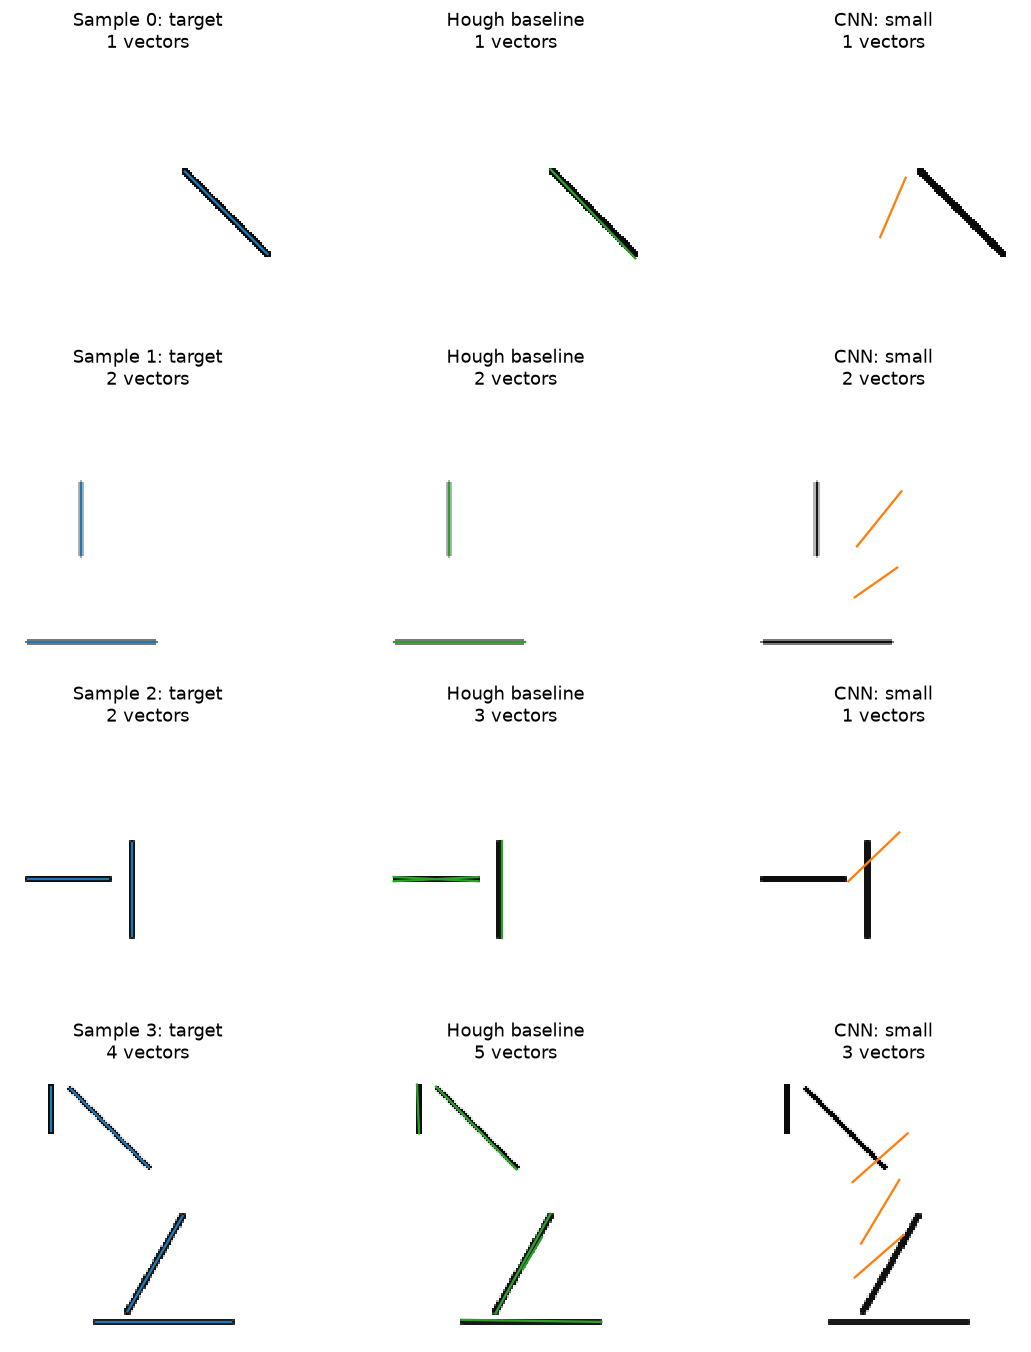

Saved visual check: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_density_four_cycle_hough_results\visual_checks\small_visual_check.png


## Cycle: Medium (20,000 training drawings)

medium | 20,000 samples | epoch 01/15: loss=0.5186, eos=0.2644, coord=0.0254
medium | 20,000 samples | epoch 02/15: loss=0.3642, eos=0.1550, coord=0.0209
medium | 20,000 samples | epoch 03/15: loss=0.3118, eos=0.1289, coord=0.0183
medium | 20,000 samples | epoch 04/15: loss=0.2912, eos=0.1165, coord=0.0175
medium | 20,000 samples | epoch 05/15: loss=0.2724, eos=0.1053, coord=0.0167
medium | 20,000 samples | epoch 06/15: loss=0.2637, eos=0.1006, coord=0.0163
medium | 20,000 samples | epoch 07/15: loss=0.2511, eos=0.0928, coord=0.0158
medium | 20,000 samples | epoch 08/15: loss=0.2453, eos=0.0908, coord=0.0155
medium | 20,000 samples | epoch 09/15: loss=0.2372, eos=0.0864, coord=0.0151
medium | 20,000 samples | epoch 10/15: loss=0.2266, eos=0.0798, coord=0.0147
medium | 20,000 samples | epoch 11/15: loss=0.2243, eos=0.0792, coord=0.0145
medium | 20,000 samples | epoch 12/15: loss=0.2165, eos=0.0748, coord=0.0142
medium | 20,000 samples | epoch 13/15: loss=0.2111, eos=0.0697, coord=0.0141

### Pixel-level performance

,Method,Precision,Recall,F1-score,Accuracy,IoU
0,Hough transform baseline,0.8993,0.4573,0.6063,0.9877,0.4350
1,CNN distance-density,0.0725,0.0264,0.0388,0.9728,0.0198


...

#### Hough transform baseline

,Predicted background,Predicted stroke
Actual background,19232538,20861
Actual stroke,221099,186302


### Engineering performance

,Method,True vectors,Predicted vectors,Vector count error,Engineering score,Line geometry score,Total length score,Junction angle score,Vector count score,True junctions,Predicted junctions
0,Hough transform baseline,3.0475,3.7525,0.7317,0.7950,0.8338,0.8646,0.6383,0.8732,0.4492,1.5650
1,CNN distance-density,3.0475,3.3483,0.3158,0.4813,0.1749,0.8095,0.5943,0.9213,0.4492,0.5625


### Visual comparison

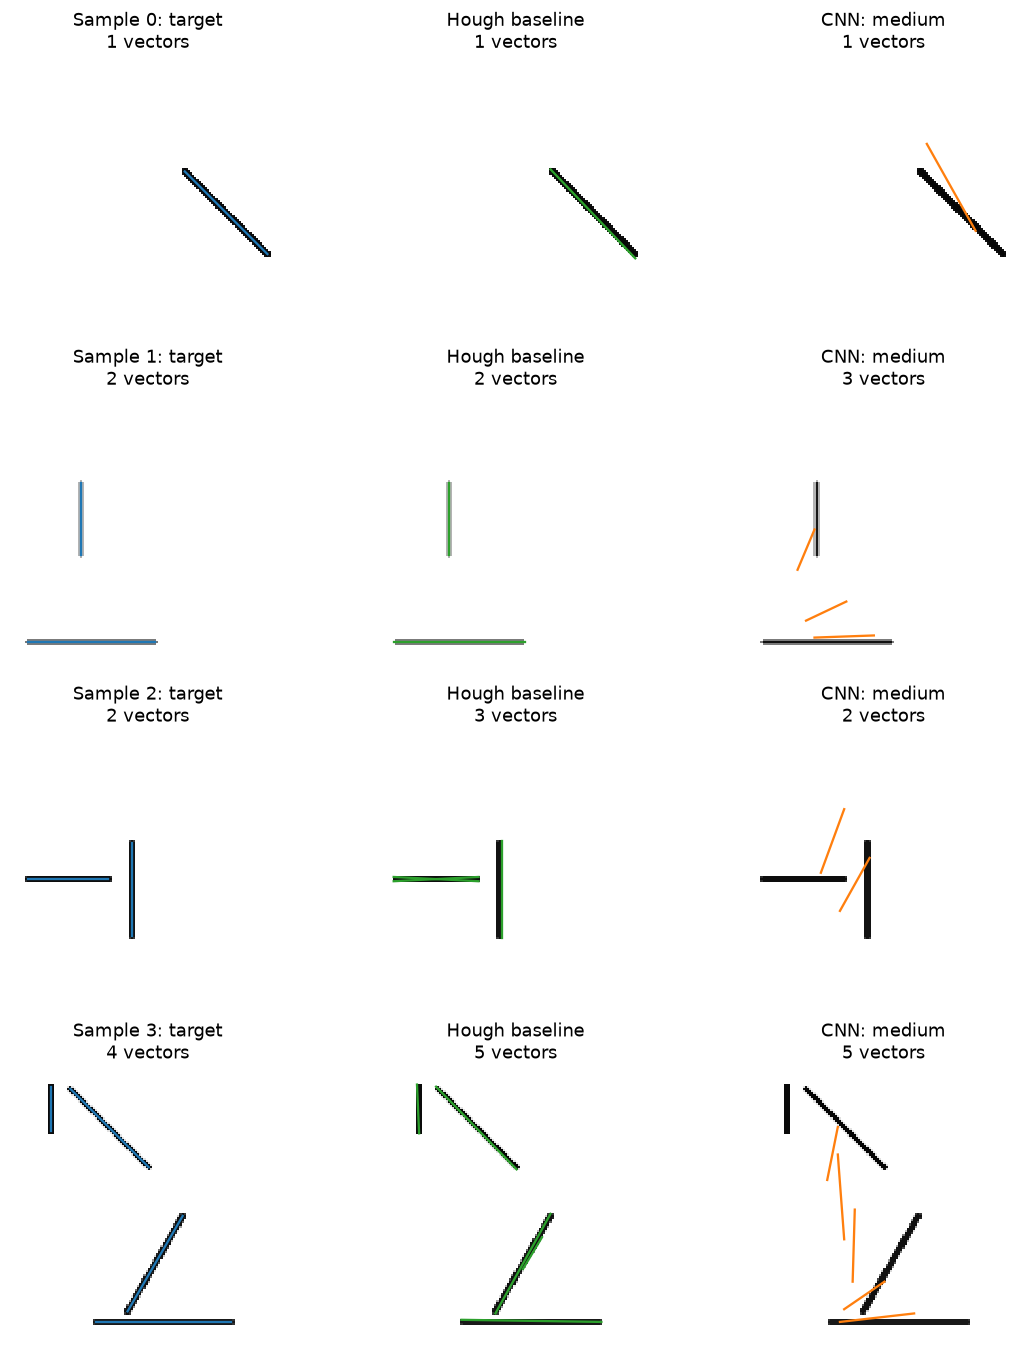

Saved visual check: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_density_four_cycle_hough_results\visual_checks\medium_visual_check.png


## Cycle: Larger (100,000 training drawings)

larger | 100,000 samples | epoch 01/15: loss=0.3568, eos=0.1582, coord=0.0199
larger | 100,000 samples | epoch 02/15: loss=0.2447, eos=0.0903, coord=0.0154
larger | 100,000 samples | epoch 03/15: loss=0.2143, eos=0.0731, coord=0.0141
larger | 100,000 samples | epoch 04/15: loss=0.1954, eos=0.0642, coord=0.0131
larger | 100,000 samples | epoch 05/15: loss=0.1770, eos=0.0557, coord=0.0121
larger | 100,000 samples | epoch 06/15: loss=0.1643, eos=0.0503, coord=0.0114
larger | 100,000 samples | epoch 07/15: loss=0.1566, eos=0.0473, coord=0.0109
larger | 100,000 samples | epoch 08/15: loss=0.1481, eos=0.0422, coord=0.0106
larger | 100,000 samples | epoch 09/15: loss=0.1427, eos=0.0392, coord=0.0103
larger | 100,000 samples | epoch 10/15: loss=0.1383, eos=0.0383, coord=0.0100
larger | 100,000 samples | epoch 11/15: loss=0.1321, eos=0.0339, coord=0.0098
larger | 100,000 samples | epoch 12/15: loss=0.1283, eos=0.0319, coord=0.0096
larger | 100,000 samples | epoch 13/15: loss=0.1270, eos=0.0322,

### Pixel-level performance

,Method,Precision,Recall,F1-score,Accuracy,IoU
0,Hough transform baseline,0.8993,0.4573,0.6063,0.9877,0.4350
1,CNN distance-density,0.0806,0.0431,0.0561,0.9700,0.0289


...

#### Hough transform baseline

,Predicted background,Predicted stroke
Actual background,19232538,20861
Actual stroke,221099,186302


### Engineering performance

,Method,True vectors,Predicted vectors,Vector count error,Engineering score,Line geometry score,Total length score,Junction angle score,Vector count score,True junctions,Predicted junctions
0,Hough transform baseline,3.0475,3.7525,0.7317,0.7950,0.8338,0.8646,0.6383,0.8732,0.4492,1.565
1,CNN distance-density,3.0475,3.4683,0.4492,0.4698,0.2033,0.7838,0.5200,0.9157,0.4492,1.465


### Visual comparison

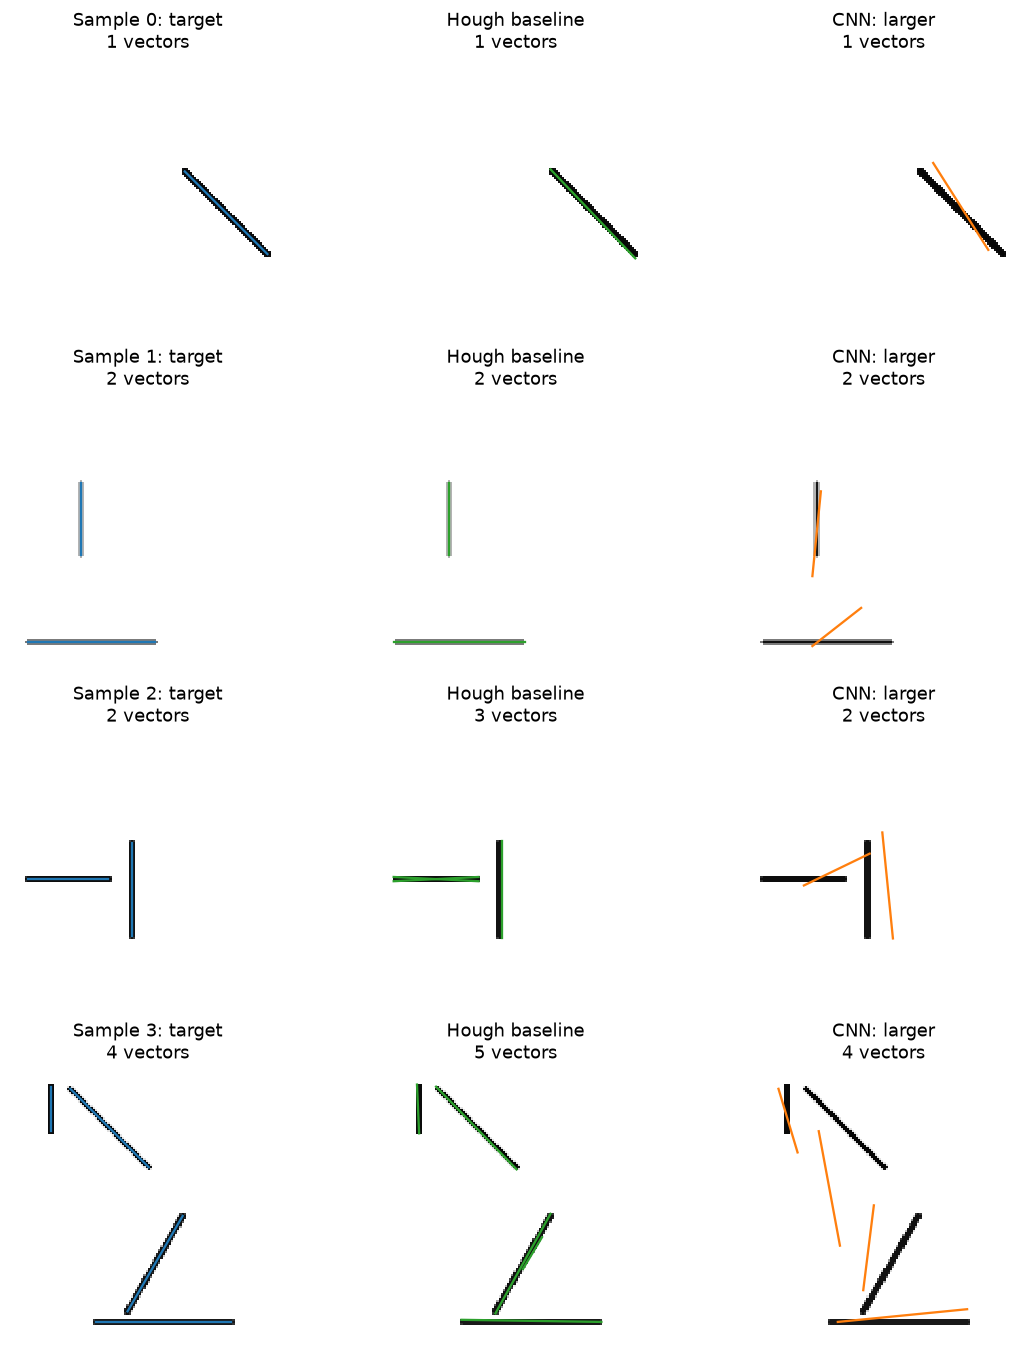

Saved visual check: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_density_four_cycle_hough_results\visual_checks\larger_visual_check.png


## Cycle: Very Large (200,000 training drawings)

very_large | 200,000 samples | epoch 01/15: loss=0.2993, eos=0.1219, coord=0.0177
very_large | 200,000 samples | epoch 02/15: loss=0.2071, eos=0.0709, coord=0.0136
very_large | 200,000 samples | epoch 03/15: loss=0.1696, eos=0.0527, coord=0.0117
very_large | 200,000 samples | epoch 04/15: loss=0.1495, eos=0.0437, coord=0.0106
very_large | 200,000 samples | epoch 05/15: loss=0.1384, eos=0.0381, coord=0.0100
very_large | 200,000 samples | epoch 06/15: loss=0.1297, eos=0.0337, coord=0.0096
very_large | 200,000 samples | epoch 07/15: loss=0.1238, eos=0.0311, coord=0.0093
very_large | 200,000 samples | epoch 08/15: loss=0.1177, eos=0.0280, coord=0.0090
very_large | 200,000 samples | epoch 09/15: loss=0.1134, eos=0.0263, coord=0.0087
very_large | 200,000 samples | epoch 10/15: loss=0.1078, eos=0.0237, coord=0.0084
very_large | 200,000 samples | epoch 11/15: loss=0.1048, eos=0.0230, coord=0.0082
very_large | 200,000 samples | epoch 12/15: loss=0.1009, eos=0.0212, coord=0.0080
very_large | 200

### Pixel-level performance

,Method,Precision,Recall,F1-score,Accuracy,IoU
0,Hough transform baseline,0.8993,0.4573,0.6063,0.9877,0.4350
1,CNN distance-density,0.0684,0.0648,0.0665,0.9623,0.0344


...

#### Hough transform baseline

,Predicted background,Predicted stroke
Actual background,19232538,20861
Actual stroke,221099,186302


### Engineering performance

,Method,True vectors,Predicted vectors,Vector count error,Engineering score,Line geometry score,Total length score,Junction angle score,Vector count score,True junctions,Predicted junctions
0,Hough transform baseline,3.0475,3.7525,0.7317,0.7950,0.8338,0.8646,0.6383,0.8732,0.4492,1.5650
1,CNN distance-density,3.0475,5.9750,2.9475,0.4044,0.2098,0.6371,0.4298,0.7516,0.4492,10.6175


### Visual comparison

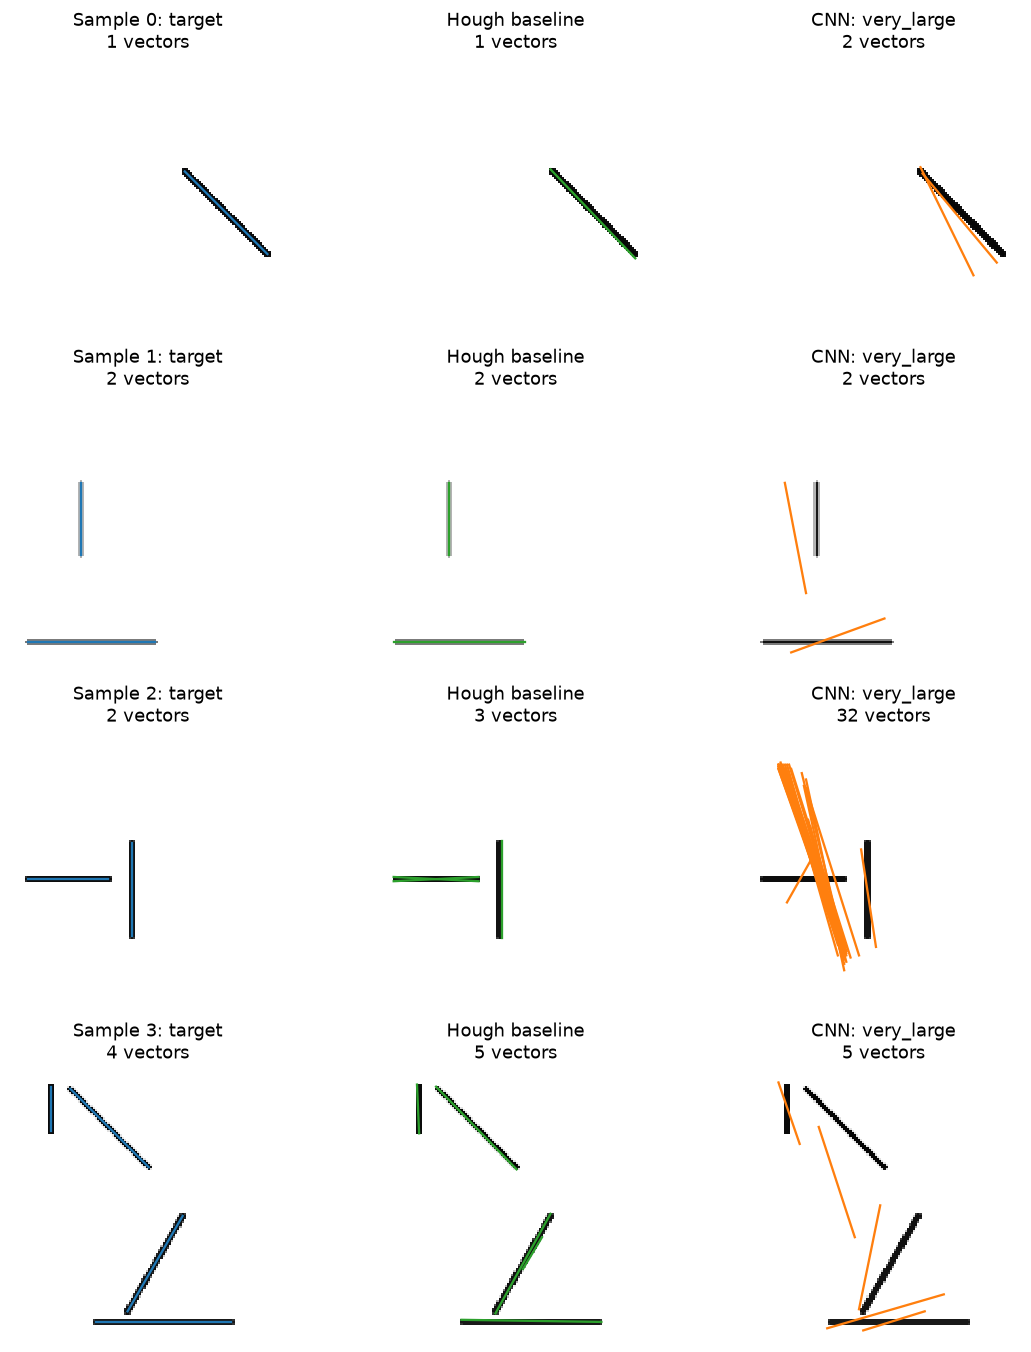

Saved visual check: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_density_four_cycle_hough_results\visual_checks\very_large_visual_check.png
All four cycles complete.


In [8]:
CNN_METHOD_NAME = 'CNN distance-density'
HOUGH_METHOD_NAME = 'Hough transform baseline'
VISUAL_SAMPLE_INDICES = [0, 1, 2, 3]


def evaluate_vector_predictions(method_name, predictions, cycle_name, n_training_samples):
    rows = []

    for sample_idx, pred_vectors in enumerate(predictions):
        raw_image = decode_uint8(test_raw_mm[sample_idx])
        true_vectors = vector_list_from_fixed(
            test_vectors_mm[sample_idx],
            test_counts_mm[sample_idx],
        )
        pred_raster = rasterise_vectors(pred_vectors, IMG_SIZE)
        pixel = raster_metrics(raw_image, pred_raster)
        engineering = engineering_metrics(true_vectors, pred_vectors, GEOMETRY_CONFIG)

        rows.append({
            'Cycle': cycle_name,
            'Training samples': int(n_training_samples),
            'sample': sample_idx,
            'Method': method_name,
            'True vectors': len(true_vectors),
            'Predicted vectors': len(pred_vectors),
            'Vector count error': abs(len(true_vectors) - len(pred_vectors)),
            'Engineering score': engineering['engineering_score'],
            'Line geometry score': engineering['line_geometry_score'],
            'Total length score': engineering['total_length_score'],
            'Junction angle score': engineering['junction_angle_score'],
            'Vector count score': engineering['vector_count_score'],
            'True junctions': engineering['true_junctions'],
            'Predicted junctions': engineering['pred_junctions'],
            'tp': pixel['tp'],
            'fp': pixel['fp'],
            'fn': pixel['fn'],
            'tn': pixel['tn'],
            'sample_precision': pixel['precision'],
            'sample_recall': pixel['recall'],
            'sample_f1': pixel['f1'],
            'sample_accuracy': pixel['accuracy'],
            'sample_iou': pixel['iou'],
        })

    return pd.DataFrame(rows)


def build_pixel_table(cycle_df):
    counts = cycle_df.groupby('Method', as_index=False).agg(
        tp=('tp', 'sum'),
        fp=('fp', 'sum'),
        fn=('fn', 'sum'),
        tn=('tn', 'sum'),
    )
    counts['Precision'] = counts['tp'] / (counts['tp'] + counts['fp'] + 1e-9)
    counts['Recall'] = counts['tp'] / (counts['tp'] + counts['fn'] + 1e-9)
    counts['F1-score'] = (
        2 * counts['Precision'] * counts['Recall']
        / (counts['Precision'] + counts['Recall'] + 1e-9)
    )
    counts['Accuracy'] = (
        counts['tp'] + counts['tn']
    ) / (
        counts['tp'] + counts['fp'] + counts['fn'] + counts['tn'] + 1e-9
    )
    counts['IoU'] = counts['tp'] / (
        counts['tp'] + counts['fp'] + counts['fn'] + 1e-9
    )

    table = counts[[
        'Method',
        'Precision',
        'Recall',
        'F1-score',
        'Accuracy',
        'IoU',
    ]].sort_values('F1-score', ascending=False).reset_index(drop=True)
    return table.round(4), counts


def build_engineering_table(cycle_df):
    table = cycle_df.groupby('Method', as_index=False).agg(
        **{
            'True vectors': ('True vectors', 'mean'),
            'Predicted vectors': ('Predicted vectors', 'mean'),
            'Vector count error': ('Vector count error', 'mean'),
            'Engineering score': ('Engineering score', 'mean'),
            'Line geometry score': ('Line geometry score', 'mean'),
            'Total length score': ('Total length score', 'mean'),
            'Junction angle score': ('Junction angle score', 'mean'),
            'Vector count score': ('Vector count score', 'mean'),
            'True junctions': ('True junctions', 'mean'),
            'Predicted junctions': ('Predicted junctions', 'mean'),
        }
    )
    return table[[
        'Method',
        'True vectors',
        'Predicted vectors',
        'Vector count error',
        'Engineering score',
        'Line geometry score',
        'Total length score',
        'Junction angle score',
        'Vector count score',
        'True junctions',
        'Predicted junctions',
    ]].sort_values('Engineering score', ascending=False).reset_index(drop=True).round(4)


def display_confusion_matrices(counts_df):
    for _, row in counts_df.sort_values('Method').iterrows():
        matrix_df = pd.DataFrame(
            [
                [int(row['tn']), int(row['fp'])],
                [int(row['fn']), int(row['tp'])],
            ],
            index=['Actual background', 'Actual stroke'],
            columns=['Predicted background', 'Predicted stroke'],
        )
        display(Markdown(f'#### {row["Method"]}'))
        display(matrix_df)


def draw_vectors(axis, image, vectors, title, colour):
    axis.imshow(image, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    for x0, y0, x1, y1 in vectors:
        axis.plot([x0, x1], [y0, y1], color=colour, linewidth=1.5)
    axis.set_title(title)
    axis.set_xlim(-1, IMG_SIZE)
    axis.set_ylim(IMG_SIZE, -1)
    axis.set_aspect('equal')
    axis.axis('off')


def display_and_save_cycle_visuals(cycle_name, cnn_predictions, hough_predictions):
    valid_indices = [idx for idx in VISUAL_SAMPLE_INDICES if idx < N_TEST]
    fig, axes = plt.subplots(
        len(valid_indices),
        3,
        figsize=(10.5, 3.1 * len(valid_indices)),
        dpi=110,
        squeeze=False,
    )

    for row_idx, sample_idx in enumerate(valid_indices):
        raw_image = decode_uint8(test_raw_mm[sample_idx])
        true_vectors = vector_list_from_fixed(
            test_vectors_mm[sample_idx],
            test_counts_mm[sample_idx],
        )
        draw_vectors(
            axes[row_idx, 0],
            raw_image,
            true_vectors,
            f'Sample {sample_idx}: target\n{len(true_vectors)} vectors',
            'tab:blue',
        )
        draw_vectors(
            axes[row_idx, 1],
            raw_image,
            hough_predictions[sample_idx],
            f'Hough baseline\n{len(hough_predictions[sample_idx])} vectors',
            'tab:green',
        )
        draw_vectors(
            axes[row_idx, 2],
            raw_image,
            cnn_predictions[sample_idx],
            f'CNN: {cycle_name}\n{len(cnn_predictions[sample_idx])} vectors',
            'tab:orange',
        )

    fig.tight_layout()
    output_path = VISUAL_DIR / f'{cycle_name}_visual_check.png'
    fig.savefig(output_path, bbox_inches='tight', dpi=140)
    plt.show()
    return output_path


# -----------------------------------------------------------------------------
# Fixed Hough baseline: calculate once and reuse in every cycle.
# -----------------------------------------------------------------------------
print(f'Evaluating fixed Hough baseline on {N_TEST:,} test drawings...')
hough_predictions = []
hough_debug_summary = []
hough_started = time.perf_counter()

for sample_idx in range(N_TEST):
    raw_image = decode_uint8(test_raw_mm[sample_idx])
    vectors, debug = reconstruct_vectors_hough_transform(raw_image)
    hough_predictions.append(vectors)
    hough_debug_summary.append({
        'sample': sample_idx,
        'candidate_peak_count': debug.get('candidate_peak_count', 0),
        'selected_peak_count': len(debug.get('selected_peaks', [])),
        'predicted_vectors': len(vectors),
    })

    if (sample_idx + 1) % 200 == 0 or sample_idx + 1 == N_TEST:
        print(f'  Hough: {sample_idx + 1:,}/{N_TEST:,} test drawings')

pd.DataFrame(hough_debug_summary).to_csv(
    OUTPUT_DIR / 'hough_debug_summary.csv',
    index=False,
)
print(f'Hough evaluation finished in {(time.perf_counter() - hough_started) / 60:.1f} minutes.')


# -----------------------------------------------------------------------------
# Four independent CNN training/evaluation cycles.
# -----------------------------------------------------------------------------
all_history_frames = []
all_result_frames = []
all_pixel_tables = []
all_engineering_tables = []
cycle_visual_files = []

for cycle_name, n_training_samples in TRAINING_CYCLES.items():
    display(Markdown(
        f'## Cycle: {cycle_name.replace("_", " ").title()} '
        f'({n_training_samples:,} training drawings)'
    ))

    model, history_df = train_cycle_model(cycle_name, n_training_samples)
    all_history_frames.append(history_df)

    model_path = MODEL_DIR / f'distance_density_{cycle_name}_{n_training_samples}.pt'
    torch.save({
        'state_dict': model.state_dict(),
        'cycle': cycle_name,
        'training_samples': int(n_training_samples),
        'model_config': DIRECT_VECTOR_MODEL_CONFIG,
        'preprocess_config': DISTANCE_DENSITY_CONFIG,
        'img_size': IMG_SIZE,
        'output_mode': 'autoregressive_until_eos',
    }, model_path)
    print('Saved model:', model_path)

    cnn_predictions = []
    for sample_idx in range(N_TEST):
        vectors, _ = predict_cnn_vectors(model, test_inputs_mm[sample_idx])
        cnn_predictions.append(vectors)

        if (sample_idx + 1) % 200 == 0 or sample_idx + 1 == N_TEST:
            print(f'  CNN evaluation: {sample_idx + 1:,}/{N_TEST:,} test drawings')

    cnn_df = evaluate_vector_predictions(
        CNN_METHOD_NAME,
        cnn_predictions,
        cycle_name,
        n_training_samples,
    )
    hough_df = evaluate_vector_predictions(
        HOUGH_METHOD_NAME,
        hough_predictions,
        cycle_name,
        n_training_samples,
    )
    cycle_df = pd.concat([cnn_df, hough_df], ignore_index=True)
    all_result_frames.append(cycle_df)

    pixel_table_df, confusion_counts_df = build_pixel_table(cycle_df)
    engineering_table_df = build_engineering_table(cycle_df)

    pixel_export = pixel_table_df.copy()
    pixel_export.insert(0, 'Training samples', int(n_training_samples))
    pixel_export.insert(0, 'Cycle', cycle_name)
    engineering_export = engineering_table_df.copy()
    engineering_export.insert(0, 'Training samples', int(n_training_samples))
    engineering_export.insert(0, 'Cycle', cycle_name)
    all_pixel_tables.append(pixel_export)
    all_engineering_tables.append(engineering_export)

    cycle_df.to_csv(CYCLE_DIR / f'{cycle_name}_per_sample_results.csv', index=False)
    pixel_table_df.to_csv(CYCLE_DIR / f'{cycle_name}_pixel_performance.csv', index=False)
    engineering_table_df.to_csv(CYCLE_DIR / f'{cycle_name}_engineering_performance.csv', index=False)
    confusion_counts_df.to_csv(CYCLE_DIR / f'{cycle_name}_confusion_counts.csv', index=False)
    history_df.to_csv(CYCLE_DIR / f'{cycle_name}_training_history.csv', index=False)

    display(Markdown('### Pixel-level performance'))
    display(pixel_table_df[[
        'Method', 'Precision', 'Recall', 'F1-score', 'Accuracy', 'IoU'
    ]])

    display(Markdown('### Confusion matrices'))
    display_confusion_matrices(confusion_counts_df)

    display(Markdown('### Engineering performance'))
    display(engineering_table_df[[
        'Method',
        'True vectors',
        'Predicted vectors',
        'Vector count error',
        'Engineering score',
        'Line geometry score',
        'Total length score',
        'Junction angle score',
        'Vector count score',
        'True junctions',
        'Predicted junctions',
    ]])

    display(Markdown('### Visual comparison'))
    visual_path = display_and_save_cycle_visuals(
        cycle_name,
        cnn_predictions,
        hough_predictions,
    )
    cycle_visual_files.append(visual_path)
    print('Saved visual check:', visual_path)

    # Predictions have been scored and selected examples retained; release the full list.
    del cnn_predictions, model
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


all_training_history_df = pd.concat(all_history_frames, ignore_index=True)
all_results_df = pd.concat(all_result_frames, ignore_index=True)
all_pixel_performance_df = pd.concat(all_pixel_tables, ignore_index=True)
all_engineering_performance_df = pd.concat(all_engineering_tables, ignore_index=True)

all_training_history_df.to_csv(OUTPUT_DIR / 'all_training_history.csv', index=False)
all_results_df.to_csv(OUTPUT_DIR / 'all_cycle_per_sample_results.csv', index=False)
all_pixel_performance_df.to_csv(OUTPUT_DIR / 'all_cycle_pixel_performance.csv', index=False)
all_engineering_performance_df.to_csv(
    OUTPUT_DIR / 'all_cycle_engineering_performance.csv',
    index=False,
)

print('All four cycles complete.')


## Cross-cycle plots

This cell creates the learning-curve and dataset-scaling plots only. The comparison tables are assembled, exported and displayed once in the final report cell, avoiding duplicated notebook output.


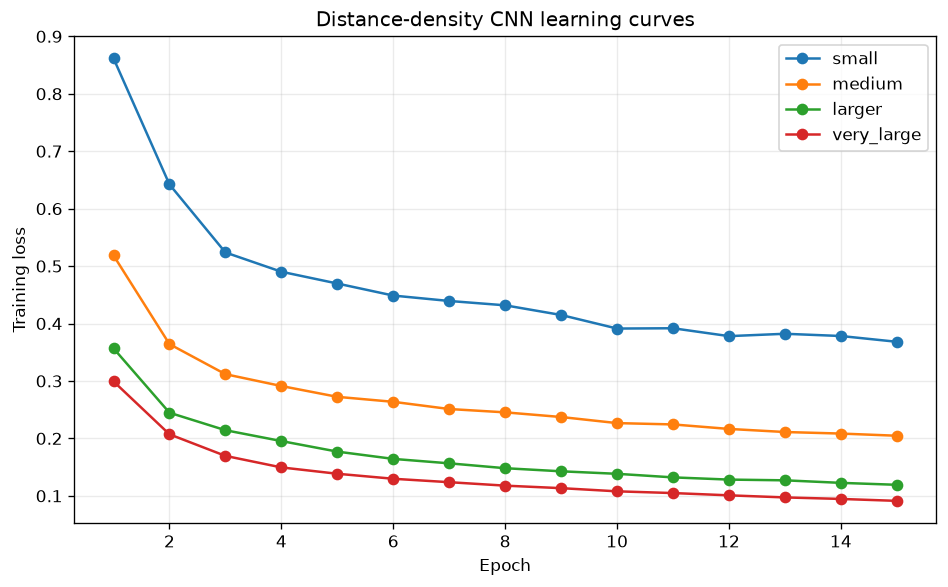

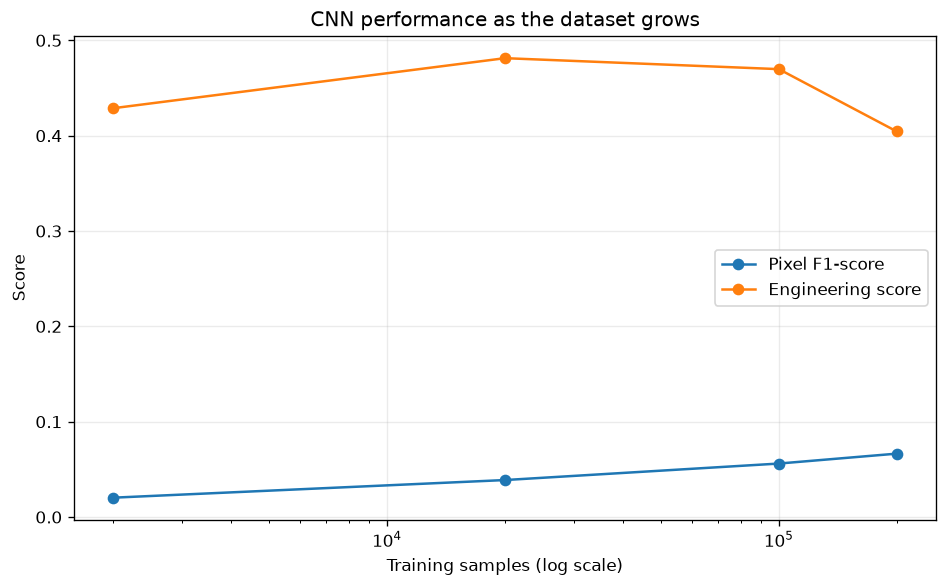

Plots saved:
  C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_density_four_cycle_hough_results\training_loss_by_cycle.png
  C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_density_four_cycle_hough_results\cnn_score_vs_training_size.png


In [9]:
# This cell intentionally contains plots only.
# Final comparison tables are displayed once in the report-output cell below.

# Training-loss curves.
fig, axis = plt.subplots(figsize=(8, 5), dpi=120)
for cycle_name, group in all_training_history_df.groupby('Cycle', sort=False):
    axis.plot(group['Epoch'], group['Loss'], marker='o', label=cycle_name)
axis.set_xlabel('Epoch')
axis.set_ylabel('Training loss')
axis.set_title('Distance-density CNN learning curves')
axis.grid(True, alpha=0.25)
axis.legend()
fig.tight_layout()
learning_curve_path = OUTPUT_DIR / 'training_loss_by_cycle.png'
fig.savefig(learning_curve_path, bbox_inches='tight', dpi=160)
plt.show()
plt.close(fig)

# CNN scaling summary; Hough is omitted because it does not use training data.
cnn_pixel_scaling = all_pixel_performance_df[
    all_pixel_performance_df['Method'] == CNN_METHOD_NAME
].sort_values('Training samples')
cnn_engineering_scaling = all_engineering_performance_df[
    all_engineering_performance_df['Method'] == CNN_METHOD_NAME
].sort_values('Training samples')

fig, axis = plt.subplots(figsize=(8, 5), dpi=120)
axis.plot(
    cnn_pixel_scaling['Training samples'],
    cnn_pixel_scaling['F1-score'],
    marker='o',
    label='Pixel F1-score',
)
axis.plot(
    cnn_engineering_scaling['Training samples'],
    cnn_engineering_scaling['Engineering score'],
    marker='o',
    label='Engineering score',
)
axis.set_xscale('log')
axis.set_xlabel('Training samples (log scale)')
axis.set_ylabel('Score')
axis.set_title('CNN performance as the dataset grows')
axis.grid(True, alpha=0.25)
axis.legend()
fig.tight_layout()
scaling_plot_path = OUTPUT_DIR / 'cnn_score_vs_training_size.png'
fig.savefig(scaling_plot_path, bbox_inches='tight', dpi=160)
plt.show()
plt.close(fig)

print('Plots saved:')
print(' ', learning_curve_path.resolve())
print(' ', scaling_plot_path.resolve())


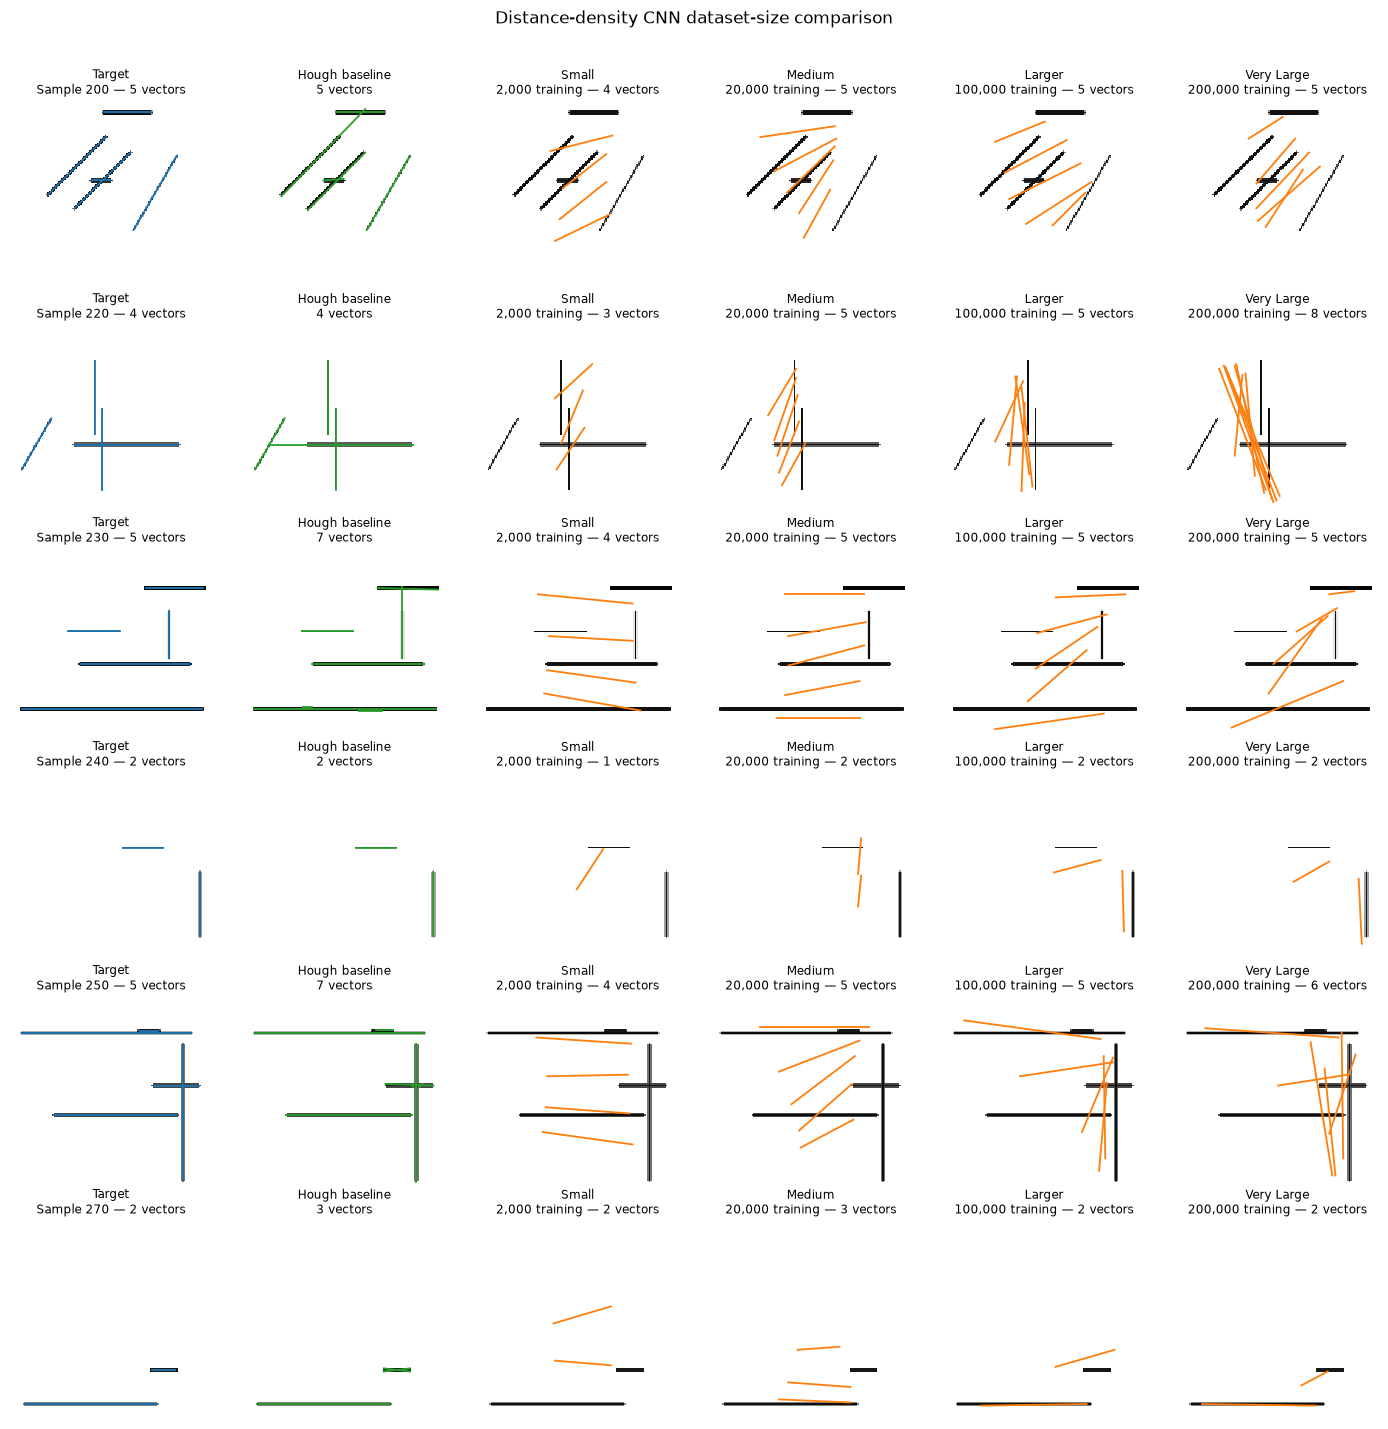

Compact side-by-side PNG saved to:
C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_density_four_cycle_hough_results\visual_checks\all_cycles_side_by_side_compact.png


In [10]:
# ============================================================================
# Compact side-by-side comparison:
# Target | Hough | Small | Medium | Larger | Very large
# ============================================================================

# Change these to select different test examples.
# Keeping this to three samples produces a manageable PNG.
SIDE_BY_SIDE_SAMPLE_INDICES = [200, 220, 230, 240, 250, 270]

SIDE_BY_SIDE_OUTPUT_PATH = (
    VISUAL_DIR / "all_cycles_side_by_side_compact.png"
)

valid_sample_indices = [
    sample_idx
    for sample_idx in SIDE_BY_SIDE_SAMPLE_INDICES
    if 0 <= sample_idx < N_TEST
]

if not valid_sample_indices:
    raise ValueError(
        "SIDE_BY_SIDE_SAMPLE_INDICES does not contain any valid test indices."
    )


def draw_compact_vectors(axis, image, vectors, title, colour):
    """Draw one compact raster/vector comparison panel."""
    axis.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )

    for x0, y0, x1, y1 in vectors:
        axis.plot(
            [x0, x1],
            [y0, y1],
            color=colour,
            linewidth=1.2,
        )

    axis.set_title(title, fontsize=8, pad=3)
    axis.set_xlim(-1, IMG_SIZE)
    axis.set_ylim(IMG_SIZE, -1)
    axis.set_aspect("equal")
    axis.axis("off")


# ---------------------------------------------------------------------------
# Generate the Hough predictions for only the selected examples.
# ---------------------------------------------------------------------------
selected_hough_predictions = {}

for sample_idx in valid_sample_indices:
    raw_image = decode_uint8(test_raw_mm[sample_idx])

    predicted_vectors, _ = reconstruct_vectors_hough_transform(
        raw_image
    )

    selected_hough_predictions[sample_idx] = predicted_vectors


# ---------------------------------------------------------------------------
# Load each saved CNN model and predict only the selected examples.
# ---------------------------------------------------------------------------
selected_cnn_predictions = {}

for cycle_name, n_training_samples in TRAINING_CYCLES.items():

    model_path = (
        MODEL_DIR
        / f"distance_density_{cycle_name}_{n_training_samples}.pt"
    )

    if not model_path.exists():
        raise FileNotFoundError(
            f"Saved model not found: {model_path}\n"
            "Run the four training cycles before running this cell."
        )

    checkpoint = torch.load(
        model_path,
        map_location=DEVICE,
    )

    model = VariableLengthLineCNN(
        input_channels=int(
            DIRECT_VECTOR_MODEL_CONFIG["input_channels"]
        ),
        hidden_dim=int(
            DIRECT_VECTOR_MODEL_CONFIG["decoder_hidden_dim"]
        ),
    ).to(DEVICE)

    model.load_state_dict(checkpoint["state_dict"])
    model.eval()

    selected_cnn_predictions[cycle_name] = {}

    for sample_idx in valid_sample_indices:
        predicted_vectors, _ = predict_cnn_vectors(
            model,
            test_inputs_mm[sample_idx],
        )

        selected_cnn_predictions[cycle_name][sample_idx] = (
            predicted_vectors
        )

    del model

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


# ---------------------------------------------------------------------------
# Draw all methods side by side.
# ---------------------------------------------------------------------------
cycle_names = list(TRAINING_CYCLES.keys())

column_count = 2 + len(cycle_names)
row_count = len(valid_sample_indices)

fig, axes = plt.subplots(
    row_count,
    column_count,
    figsize=(2.15 * column_count, 2.15 * row_count),
    dpi=110,
    squeeze=False,
)

for row_index, sample_idx in enumerate(valid_sample_indices):

    raw_image = decode_uint8(test_raw_mm[sample_idx])

    true_vectors = vector_list_from_fixed(
        test_vectors_mm[sample_idx],
        test_counts_mm[sample_idx],
    )

    # Target
    draw_compact_vectors(
        axes[row_index, 0],
        raw_image,
        true_vectors,
        (
            f"Target\n"
            f"Sample {sample_idx} — {len(true_vectors)} vectors"
        ),
        "tab:blue",
    )

    # Hough baseline
    hough_vectors = selected_hough_predictions[sample_idx]

    draw_compact_vectors(
        axes[row_index, 1],
        raw_image,
        hough_vectors,
        f"Hough baseline\n{len(hough_vectors)} vectors",
        "tab:green",
    )

    # CNN cycles: small, medium, larger and very large
    for cycle_column, cycle_name in enumerate(
        cycle_names,
        start=2,
    ):
        cnn_vectors = selected_cnn_predictions[
            cycle_name
        ][sample_idx]

        training_samples = TRAINING_CYCLES[cycle_name]

        display_cycle_name = cycle_name.replace(
            "_",
            " ",
        ).title()

        draw_compact_vectors(
            axes[row_index, cycle_column],
            raw_image,
            cnn_vectors,
            (
                f"{display_cycle_name}\n"
                f"{training_samples:,} training — "
                f"{len(cnn_vectors)} vectors"
            ),
            "tab:orange",
        )

fig.suptitle(
    "Distance-density CNN dataset-size comparison",
    fontsize=11,
    y=1.002,
)

fig.subplots_adjust(
    left=0.01,
    right=0.99,
    top=0.94,
    bottom=0.01,
    wspace=0.04,
    hspace=0.12,
)

fig.savefig(
    SIDE_BY_SIDE_OUTPUT_PATH,
    dpi=160,
    bbox_inches="tight",
    pad_inches=0.05,
    facecolor="white",
)

plt.show()
plt.close(fig)

print("Compact side-by-side PNG saved to:")
print(SIDE_BY_SIDE_OUTPUT_PATH.resolve())


In [11]:
# Run after the four-cycle experiment cell.
# Dataset files are not changed. All report files go to a separate folder.

from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import display, Markdown


# -------------------------------------------------------------------------
# Checks
# -------------------------------------------------------------------------

required = [
    'all_results_df',
    'all_training_history_df',
    'TRAINING_CYCLES',
    'CNN_METHOD_NAME',
    'HOUGH_METHOD_NAME',
    'DIRECT_VECTOR_MODEL_CONFIG',
    'DISTANCE_DENSITY_CONFIG',
    'CLASSIC_VECTOR_CONFIG',
    'GEOMETRY_CONFIG',
    'IMG_SIZE',
    'MAX_VECTORS',
    'N_TRAIN_IMAGES',
    'N_TEST',
    'BATCH_SIZE',
    'CNN_EPOCHS',
    'LEARNING_RATE',
    'MIN_VECTOR_LENGTH',
]

missing = [
    name
    for name in required
    if name not in globals()
]

if missing:
    raise NameError(
        "Run the earlier setup, training and evaluation cells first. "
        "Missing: " + ", ".join(missing)
    )

if all_results_df.empty:
    raise ValueError(
        "all_results_df is empty. "
        "Run the four-cycle experiment first."
    )


# -------------------------------------------------------------------------
# New output folder
# -------------------------------------------------------------------------

REPORT_OUTPUT_FOLDER_NAME = (
    "cnn_distance_density_variable_length_hough_report_outputs"
)

REPORT_OUTPUT_DIR = Path(REPORT_OUTPUT_FOLDER_NAME)
REPORT_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

if (
    "OUTPUT_DIR" in globals()
    and REPORT_OUTPUT_DIR.resolve() == Path(OUTPUT_DIR).resolve()
):
    raise ValueError(
        "REPORT_OUTPUT_DIR must be different from OUTPUT_DIR."
    )


# -------------------------------------------------------------------------
# Display settings
# -------------------------------------------------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:.4f}".format)


# -------------------------------------------------------------------------
# Build the comparison dataset
#
# Hough is identical in every training cycle, so it is included once.
# Every CNN training cycle is treated as a separate report method.
# -------------------------------------------------------------------------

source_df = all_results_df.copy()

first_cycle = next(iter(TRAINING_CYCLES))

cnn_df = source_df[
    source_df["Method"] == CNN_METHOD_NAME
].copy()

hough_df = source_df[
    (source_df["Method"] == HOUGH_METHOD_NAME)
    & (source_df["Cycle"] == first_cycle)
].copy()

if cnn_df.empty:
    raise ValueError(
        f"No CNN results named {CNN_METHOD_NAME!r} were found."
    )

if hough_df.empty:
    raise ValueError(
        f"No Hough results named {HOUGH_METHOD_NAME!r} were found."
    )

# Hough has no training cycle or training sample count.
hough_df["Cycle"] = "baseline"
hough_df["Training samples"] = 0

comparison_df = pd.concat(
    [
        cnn_df,
        hough_df,
    ],
    ignore_index=True,
)

comparison_df = comparison_df.rename(
    columns={
        "Method": "Base method",
    }
)


def make_method_name(row):
    if row["Base method"] == HOUGH_METHOD_NAME:
        return HOUGH_METHOD_NAME

    cycle_name = (
        str(row["Cycle"])
        .replace("_", " ")
        .title()
    )

    training_samples = int(
        row["Training samples"]
    )

    return (
        f"{CNN_METHOD_NAME} — {cycle_name} "
        f"({training_samples:,} training samples)"
    )


comparison_df["Method"] = comparison_df.apply(
    make_method_name,
    axis=1,
)

comparison_df = comparison_df[
    [
        "Method",
        "Base method",
        "Cycle",
        "Training samples",
        "sample",

        "True vectors",
        "Predicted vectors",
        "Vector count error",

        "Engineering score",
        "Line geometry score",
        "Total length score",
        "Junction angle score",
        "Vector count score",
        "True junctions",
        "Predicted junctions",

        "tp",
        "fp",
        "fn",
        "tn",

        "sample_precision",
        "sample_recall",
        "sample_f1",
        "sample_accuracy",
        "sample_iou",
    ]
]


# -------------------------------------------------------------------------
# Average method comparison
# -------------------------------------------------------------------------

summary_df = (
    comparison_df
    .groupby("Method")
    .mean(numeric_only=True)
    .sort_values(
        "Engineering score",
        ascending=False,
    )
    .round(4)
)


# -------------------------------------------------------------------------
# Confusion-matrix totals
# -------------------------------------------------------------------------

confusion_summary_df = (
    comparison_df
    .groupby("Method")[
        [
            "tp",
            "fp",
            "fn",
            "tn",
        ]
    ]
    .sum()
    .sort_index()
)


# -------------------------------------------------------------------------
# F1 / accuracy / engineering matrix
# -------------------------------------------------------------------------

f1_accuracy_matrix_df = (
    comparison_df
    .groupby("Method")
    .agg(
        tp=("tp", "sum"),
        fp=("fp", "sum"),
        fn=("fn", "sum"),
        tn=("tn", "sum"),

        mean_precision=(
            "sample_precision",
            "mean",
        ),
        mean_recall=(
            "sample_recall",
            "mean",
        ),
        mean_f1=(
            "sample_f1",
            "mean",
        ),
        mean_accuracy=(
            "sample_accuracy",
            "mean",
        ),
        mean_iou=(
            "sample_iou",
            "mean",
        ),

        mean_engineering_score=(
            "Engineering score",
            "mean",
        ),
        mean_vector_count_error=(
            "Vector count error",
            "mean",
        ),
        mean_pred_vectors=(
            "Predicted vectors",
            "mean",
        ),
    )
)

f1_accuracy_matrix_df["global_precision"] = (
    f1_accuracy_matrix_df["tp"]
    / (
        f1_accuracy_matrix_df["tp"]
        + f1_accuracy_matrix_df["fp"]
        + 1e-9
    )
)

f1_accuracy_matrix_df["global_recall"] = (
    f1_accuracy_matrix_df["tp"]
    / (
        f1_accuracy_matrix_df["tp"]
        + f1_accuracy_matrix_df["fn"]
        + 1e-9
    )
)

f1_accuracy_matrix_df["global_f1"] = (
    2
    * f1_accuracy_matrix_df["global_precision"]
    * f1_accuracy_matrix_df["global_recall"]
    / (
        f1_accuracy_matrix_df["global_precision"]
        + f1_accuracy_matrix_df["global_recall"]
        + 1e-9
    )
)

f1_accuracy_matrix_df["global_accuracy"] = (
    f1_accuracy_matrix_df["tp"]
    + f1_accuracy_matrix_df["tn"]
) / (
    f1_accuracy_matrix_df["tp"]
    + f1_accuracy_matrix_df["fp"]
    + f1_accuracy_matrix_df["fn"]
    + f1_accuracy_matrix_df["tn"]
    + 1e-9
)

f1_accuracy_matrix_df["global_iou"] = (
    f1_accuracy_matrix_df["tp"]
    / (
        f1_accuracy_matrix_df["tp"]
        + f1_accuracy_matrix_df["fp"]
        + f1_accuracy_matrix_df["fn"]
        + 1e-9
    )
)

f1_accuracy_matrix_df = (
    f1_accuracy_matrix_df
    .round(4)
)

score_matrix_df = (
    f1_accuracy_matrix_df[
        [
            "global_precision",
            "global_recall",
            "global_f1",
            "global_accuracy",
            "global_iou",

            "mean_precision",
            "mean_recall",
            "mean_f1",
            "mean_accuracy",
            "mean_iou",

            "mean_engineering_score",
            "mean_vector_count_error",
            "mean_pred_vectors",

            "tp",
            "fp",
            "fn",
            "tn",
        ]
    ]
    .sort_values(
        "mean_engineering_score",
        ascending=False,
    )
)


# -------------------------------------------------------------------------
# Clean table 1:
# Method, Precision, Recall, F1-score, Accuracy and IoU
# -------------------------------------------------------------------------

performance_table_df = (
    f1_accuracy_matrix_df
    .reset_index()
    .rename(
        columns={
            "global_precision": "Precision",
            "global_recall": "Recall",
            "global_f1": "F1-score",
            "global_accuracy": "Accuracy",
            "global_iou": "IoU",
        }
    )
    [
        [
            "Method",
            "Precision",
            "Recall",
            "F1-score",
            "Accuracy",
            "IoU",
        ]
    ]
    .sort_values(
        "F1-score",
        ascending=False,
    )
    .reset_index(drop=True)
    .round(4)
)


# -------------------------------------------------------------------------
# Clean table 2:
# Vector and engineering metrics
# -------------------------------------------------------------------------

engineering_table_df = (
    comparison_df
    .groupby(
        "Method",
        as_index=False,
    )
    .agg(
        **{
            "True vectors": (
                "True vectors",
                "mean",
            ),
            "Predicted vectors": (
                "Predicted vectors",
                "mean",
            ),
            "Vector count error": (
                "Vector count error",
                "mean",
            ),
            "Engineering score": (
                "Engineering score",
                "mean",
            ),
            "Line geometry score": (
                "Line geometry score",
                "mean",
            ),
            "Total length score": (
                "Total length score",
                "mean",
            ),
            "Junction angle score": (
                "Junction angle score",
                "mean",
            ),
            "Vector count score": (
                "Vector count score",
                "mean",
            ),
            "True junctions": (
                "True junctions",
                "mean",
            ),
            "Predicted junctions": (
                "Predicted junctions",
                "mean",
            ),
        }
    )
    [
        [
            "Method",
            "True vectors",
            "Predicted vectors",
            "Vector count error",
            "Engineering score",
            "Line geometry score",
            "Total length score",
            "Junction angle score",
            "Vector count score",
            "True junctions",
            "Predicted junctions",
        ]
    ]
    .sort_values(
        "Engineering score",
        ascending=False,
    )
    .reset_index(drop=True)
    .round(4)
)


# -------------------------------------------------------------------------
# Constants table
# -------------------------------------------------------------------------

constants_df = pd.DataFrame(
    [
        [
            "Image size",
            IMG_SIZE,
            "Dataset, CNN and Hough",
        ],
        [
            "Dataset maximum vectors",
            MAX_VECTORS,
            "Existing dataset generation/storage only",
        ],
        [
            "CNN architectural maximum vectors",
            "None",
            "Autoregressive decoding until learned EOS",
        ],
        [
            "Hough maximum returned vectors",
            "None",
            "All accepted Hough segments",
        ],
        [
            "Maximum training drawings",
            N_TRAIN_IMAGES,
            "Dataset",
        ],
        [
            "Test drawings",
            N_TEST,
            "All methods",
        ],
        [
            "Batch size",
            BATCH_SIZE,
            "CNN training",
        ],
        [
            "Epochs per cycle",
            CNN_EPOCHS,
            "CNN training",
        ],
        [
            "Learning rate",
            LEARNING_RATE,
            "CNN training",
        ],
        [
            "Minimum output vector length",
            MIN_VECTOR_LENGTH,
            "CNN/Hough cleanup",
        ],
        [
            "Report output folder",
            REPORT_OUTPUT_FOLDER_NAME,
            "This cell only",
        ],
    ],
    columns=[
        "Parameter",
        "Value",
        "Applies to",
    ],
)


# -------------------------------------------------------------------------
# Methods-compared table
# -------------------------------------------------------------------------

methods_rows = []

for cycle_name, training_count in TRAINING_CYCLES.items():
    cycle_display = (
        str(cycle_name)
        .replace("_", " ")
        .title()
    )

    methods_rows.append(
        {
            "Method": (
                f"{CNN_METHOD_NAME} — {cycle_display} "
                f"({int(training_count):,} training samples)"
            ),
            "Method type": "Machine learning",
            "Training samples": int(training_count),
            "Output rule": (
                "Autoregressive vectors until learned EOS"
            ),
            "Hard vector-count maximum": "None",
        }
    )

methods_rows.append(
    {
        "Method": HOUGH_METHOD_NAME,
        "Method type": "Classical baseline",
        "Training samples": "Not applicable",
        "Output rule": (
            "All accepted, non-suppressed Hough segments"
        ),
        "Hard vector-count maximum": "None",
    }
)

methods_compared_df = pd.DataFrame(
    methods_rows
)


# -------------------------------------------------------------------------
# Output file paths
# -------------------------------------------------------------------------

files = {
    "Per-sample results": (
        REPORT_OUTPUT_DIR
        / "comparison_per_sample_results.csv"
    ),
    "Average summary": (
        REPORT_OUTPUT_DIR
        / "comparison_summary.csv"
    ),
    "Confusion totals": (
        REPORT_OUTPUT_DIR
        / "confusion_matrix_totals.csv"
    ),
    "F1/accuracy matrix": (
        REPORT_OUTPUT_DIR
        / "f1_accuracy_matrix.csv"
    ),
    "Score matrix": (
        REPORT_OUTPUT_DIR
        / "score_matrix.csv"
    ),
    "Performance table": (
        REPORT_OUTPUT_DIR
        / "performance_table.csv"
    ),
    "Engineering table": (
        REPORT_OUTPUT_DIR
        / "engineering_table.csv"
    ),
    "Training history": (
        REPORT_OUTPUT_DIR
        / "training_history.csv"
    ),
    "Methods compared": (
        REPORT_OUTPUT_DIR
        / "methods_compared.csv"
    ),
    "Run constants": (
        REPORT_OUTPUT_DIR
        / "run_constants.csv"
    ),
    "Run configuration": (
        REPORT_OUTPUT_DIR
        / "report_run_config.json"
    ),
}


# -------------------------------------------------------------------------
# Save CSV outputs
# -------------------------------------------------------------------------

comparison_df.to_csv(
    files["Per-sample results"],
    index=False,
)

summary_df.to_csv(
    files["Average summary"],
)

confusion_summary_df.to_csv(
    files["Confusion totals"],
)

f1_accuracy_matrix_df.to_csv(
    files["F1/accuracy matrix"],
)

score_matrix_df.to_csv(
    files["Score matrix"],
)

performance_table_df.to_csv(
    files["Performance table"],
    index=False,
)

engineering_table_df.to_csv(
    files["Engineering table"],
    index=False,
)

all_training_history_df.to_csv(
    files["Training history"],
    index=False,
)

methods_compared_df.to_csv(
    files["Methods compared"],
    index=False,
)

constants_df.to_csv(
    files["Run constants"],
    index=False,
)


# -------------------------------------------------------------------------
# Save run configuration
# -------------------------------------------------------------------------

report_config = {
    "report_output_folder": (
        REPORT_OUTPUT_FOLDER_NAME
    ),
    "dataset_unchanged": True,

    "dataset_max_vectors": int(
        MAX_VECTORS
    ),
    "dataset_max_vectors_applies_to": (
        "dataset generation/storage only"
    ),

    "cnn_hard_vector_count_maximum": None,
    "cnn_output_mode": (
        "autoregressive_until_learned_eos"
    ),

    "hough_hard_vector_count_maximum": None,

    "training_cycles": {
        str(name): int(count)
        for name, count in TRAINING_CYCLES.items()
    },

    "test_drawings": int(N_TEST),

    "cnn_model_config": (
        DIRECT_VECTOR_MODEL_CONFIG
    ),
    "distance_density_config": (
        DISTANCE_DENSITY_CONFIG
    ),
    "hough_config": (
        CLASSIC_VECTOR_CONFIG["hough"]
    ),
    "geometry_config": (
        GEOMETRY_CONFIG
    ),
}

files["Run configuration"].write_text(
    json.dumps(
        report_config,
        indent=2,
    ),
    encoding="utf-8",
)


# -------------------------------------------------------------------------
# Notebook output
# -------------------------------------------------------------------------

print(
    "\nComparison export complete."
)

print(
    "New report folder:",
    REPORT_OUTPUT_DIR.resolve(),
)

print(
    "The existing synthetic dataset folder was not modified."
)


display(
    Markdown(
        "# CNN distance-density and Hough comparison"
    )
)


display(
    Markdown(
        "## Data / run constants"
    )
)

display(
    constants_df
)


display(
    Markdown(
        "## CNN model config"
    )
)

display(
    pd.DataFrame(
        [DIRECT_VECTOR_MODEL_CONFIG]
    )
)


display(
    Markdown(
        "## Hough baseline config"
    )
)

display(
    pd.DataFrame(
        [CLASSIC_VECTOR_CONFIG["hough"]]
    )
)


display(
    Markdown(
        "## Methods compared"
    )
)

display(
    methods_compared_df
)


# -------------------------------------------------------------------------
# Two report-ready tables
# -------------------------------------------------------------------------

display(
    Markdown(
        "## Pixel-level performance by method"
    )
)

display(
    performance_table_df
)


display(
    Markdown(
        "## Engineering performance by method"
    )
)

display(
    engineering_table_df
)


# -------------------------------------------------------------------------
# Detailed tables
# -------------------------------------------------------------------------

display(
    Markdown(
        "## Average method comparison"
    )
)

display(
    summary_df
)


display(
    Markdown(
        "## F1 / Accuracy / Engineering Score Matrix"
    )
)

display(
    score_matrix_df
)


display(
    Markdown(
        "## Confusion matrix totals by method"
    )
)

display(
    confusion_summary_df
)


# -------------------------------------------------------------------------
# Individual confusion matrices
# -------------------------------------------------------------------------

display(
    Markdown(
        "## Individual confusion matrices"
    )
)

for method_name, row in confusion_summary_df.iterrows():
    matrix = np.array(
        [
            [
                int(row["tn"]),
                int(row["fp"]),
            ],
            [
                int(row["fn"]),
                int(row["tp"]),
            ],
        ]
    )

    matrix_display_df = pd.DataFrame(
        matrix,
        index=[
            "true_background",
            "true_stroke",
        ],
        columns=[
            "pred_background",
            "pred_stroke",
        ],
    )

    display(
        Markdown(
            f"### {method_name}"
        )
    )

    display(
        matrix_display_df
    )


# -------------------------------------------------------------------------
# Per-sample preview
# -------------------------------------------------------------------------

display(
    Markdown(
        "## First few per-sample rows"
    )
)

display(
    comparison_df.head(10)
)


# -------------------------------------------------------------------------
# Saved files
# -------------------------------------------------------------------------

display(
    Markdown(
        "## Saved files"
    )
)

saved_files_df = pd.DataFrame(
    {
        "Output": list(
            files.keys()
        ),
        "File": list(
            files.values()
        ),
    }
)

display(
    saved_files_df
)


Comparison export complete.
New report folder: C:\Users\elmak\Documents\GitHub\Understanding-Artificial-Intelligence\vectorization-project\cnn_distance_density_variable_length_hough_report_outputs
The existing synthetic dataset folder was not modified.


# CNN distance-density and Hough comparison

## Data / run constants

,Parameter,Value,Applies to
0,Image size,128,"Dataset, CNN and Hough"
1,Dataset maximum vectors,5,Existing dataset generation/storage only
2,CNN architectural maximum vectors,None,Autoregressive decoding until learned EOS
3,Hough maximum returned vectors,None,All accepted Hough segments
4,Maximum training drawings,200000,Dataset
5,Test drawings,1200,All methods
6,Batch size,128,CNN training
7,Epochs per cycle,15,CNN training
8,Learning rate,0.0003,CNN training
9,Minimum output vector length,2.0000,CNN/Hough cleanup


## CNN model config

...

,pred_background,pred_stroke
true_background,19232538,20861
true_stroke,221099,186302


## First few per-sample rows

,Method,Base method,Cycle,Training samples,sample,True vectors,Predicted vectors,Vector count error,Engineering score,Line geometry score,Total length score,Junction angle score,Vector count score,True junctions,Predicted junctions,tp,fp,fn,tn,sample_precision,sample_recall,sample_f1,sample_accuracy,sample_iou
0,"CNN distance-density — Small (2,000 training samples)",CNN distance-density,small,2000,0,1,1,0,0.4591,0.0000,0.5455,1.0000,1.0000,0,0,0,29,204,16151,0.0000,0.0000,0.0000,0.9858,0.0000
1,"CNN distance-density — Small (2,000 training samples)",CNN distance-density,small,2000,1,2,2,0,0.5346,0.1407,0.6064,1.0000,1.0000,0,0,0,48,220,16116,0.0000,0.0000,0.0000,0.9836,0.0000
2,"CNN distance-density — Small (2,000 training samples)",CNN distance-density,small,2000,2,2,1,1,0.3902,0.0215,0.4024,1.0000,0.5000,0,0,3,22,261,16098,0.1200,0.0114,0.0208,0.9827,0.0105
3,"CNN distance-density — Small (2,000 training samples)",CNN distance-density,small,2000,3,4,3,1,0.4620,0.0693,0.5291,1.0000,0.7500,0,0,3,79,558,15744,0.0366,0.0053,0.0093,0.9611,0.0047
4,"CNN distance-density — Small (2,000 training samples)",CNN distance-density,small,2000,4,4,4,0,0.4751,0.0557,0.5000,1.0000,1.0000,0,0,11,119,693,15561,0.0846,0.0156,0.0264,0.9504,0.0134
5,"CNN distance-density — Small (2,000 training samples)",CNN distance-density,small,2000,5,5,5,0,0.3662,0.1470,1.0000,0.0000,1.0000,1,0,17,163,451,15753,0.0944,0.0363,0.0525,0.9625,0.0269
6,"CNN distance-density — Small (2,000 training samples)",CNN distance-density,small,2000,6,1,1,0,0.6294,0.2042,0.9375,1.0000,1.0000,0,0,0,26,101,16257,0.0000,0.0000,0.0000,0.9922,0.0000
7,"CNN distance-density — Small (2,000 training samples)",CNN distance-density,small,2000,7,4,4,0,0.5587,0.0658,0.8952,1.0000,1.0000,0,0,0,231,283,15870,0.0000,0.0000,0.0000,0.9686,0.0000
8,"CNN distance-density — Small (2,000 training samples)",CNN distance-density,small,2000,8,3,3,0,0.2850,0.1167,0.6627,0.0000,1.0000,1,0,2,106,252,16024,0.0185,0.0079,0.0110,0.9781,0.0056
9,"CNN distance-density — Small (2,000 training samples)",CNN distance-density,small,2000,9,2,1,1,0.4497,0.0300,0.6809,1.0000,0.5000,0,0,0,28,132,16224,0.0000,0.0000,0.0000,0.9902,0.0000


## Saved files

,Output,File
0,Per-sample results,cnn_distance_density_variable_length_hough_report_outputs\comparison_per_sample_results.csv
1,Average summary,cnn_distance_density_variable_length_hough_report_outputs\comparison_summary.csv
2,Confusion totals,cnn_distance_density_variable_length_hough_report_outputs\confusion_matrix_totals.csv
3,F1/accuracy matrix,cnn_distance_density_variable_length_hough_report_outputs\f1_accuracy_matrix.csv
4,Score matrix,cnn_distance_density_variable_length_hough_report_outputs\score_matrix.csv
5,Performance table,cnn_distance_density_variable_length_hough_report_outputs\performance_table.csv
6,Engineering table,cnn_distance_density_variable_length_hough_report_outputs\engineering_table.csv
7,Training history,cnn_distance_density_variable_length_hough_report_outputs\training_history.csv
8,Methods compared,cnn_distance_density_variable_length_hough_report_outputs\methods_compared.csv
9,Run constants,cnn_distance_density_variable_length_hough_report_outputs\run_constants.csv


## Experiment notes

- The synthetic drawing distribution, dataset vector limit, line widths, fade range, angle-family weights and rasterisation logic are unchanged.
- The exported arrays still use the original fixed-width vector storage because that is a dataset format detail, not a model output limit.
- `distance_density` is the only CNN input method. It is a two-channel input, not two separately trained preprocessing models.
- The CNN uses an autoregressive decoder: it emits vectors sequentially and learns when to emit end-of-sequence. It does not receive `MAX_VECTORS` and has no fixed vector-slot head.
- Because the unchanged training data contains at most five vectors, predictions above five are architecturally possible but are not supported by examples in this dataset; reliable extrapolation would require training examples with larger counts.
- All cycles use nested prefixes of one exported dataset sized automatically to the largest value in `TRAINING_CYCLES`.
- All cycles use the same 1,200-sample test set, 15 epochs and learning rate of `3e-4`.
- Every CNN starts from the same model seed so dataset size is the principal changed factor.
- The Hough transform is non-learning and is therefore evaluated once, then shown beside every CNN cycle.
- The Hough routine processes every valid accumulator candidate and does not impose a maximum returned-line count.
- The Hough routine uses the thresholded original raster supplied to it and does not apply internal skeletonisation.
- Large arrays are memory-mapped from the `synthetic_dataset` subfolder to avoid loading the complete dataset into RAM.
- Change the values in `TRAINING_CYCLES` to resize the experiments. The export size, manifest compatibility check and regeneration all update automatically.
